# Setup

### Facer

In [ ]:
!pip install git+https://github.com/FacePerceiver/facer.git@main
!pip install timm

  Cloning https://github.com/FacePerceiver/facer.git (to revision main) to /tmp/pip-req-build-2c5fvp2v
  Running command git clone --filter=blob:none --quiet https://github.com/FacePerceiver/facer.git /tmp/pip-req-build-2c5fvp2v
  Resolved https://github.com/FacePerceiver/facer.git to commit ddd35c76ff840174b8a5403ad1c1255e37b8782b
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s

In [ ]:
!pip install pyfacer

### Library



import cv2
import os
import zipfile
import shutil
import facer
import numpy as np
asarray = np.asarray
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance
from PIL import Image
from mlxtend.plotting import plot_decision_regions
from IPython.display import clear_output
from sklearn.decomposition import PCA
import random
import time
import colorsys
import PIL
import tensorflow as tf
import math
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity # Example: import euclidean_distances
from sklearn.neighbors import BallTree # This line is changed
from mpl_toolkits.mplot3d import Axes3D
BallTree.valid_metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import glob
from sklearn.utils import shuffle
import tqdm

In [ ]:
import torch
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial import distance
import matplotlib.pyplot as plt
from PIL import Image
from skimage import color
import cv2

# Colors

In [ ]:
# Authority: https://icolorpalette.com/

# Blond
canonicalBlond = "C2A269"
canonicalDarkBlond = "91723a"
_BlondColors = set([
    canonicalBlond
])
_darkBlondColors = set([
    canonicalDarkBlond
])

# Brown
canonicalBrown = "5C4033"
canonicalDarkBrown = "34241d"
_BrownColors = set([
    canonicalBrown
])
_darkBrownColors = set([
    canonicalDarkBrown
])

# Black hair
canonicalBlack = "000000"
_blackColors = set([
    canonicalBlack
])

# Red hair
canonicalRed = "681a1a"
_redColors = set([
    canonicalRed
])


# Grey hair
canonicalGrey = "515151"
_greyColors = set([
    canonicalGrey
])



In [ ]:
# Final colorSpaces dictionary
colorSpaces = {
    "black": _blackColors,
    "brown": _BrownColors,
    "dark_brown": _darkBrownColors,
    "blonde": _BlondColors,
    "dark_blonde": _darkBlondColors,
    "red": _redColors,
    "grey": _greyColors
}

# Output the hair color categories this program classifies
print(f"This program classifies into {colorSpaces.keys()}")

This program classifies into dict_keys(['black', 'brown', 'dark_brown', 'blonde', 'dark_blonde', 'red', 'grey'])


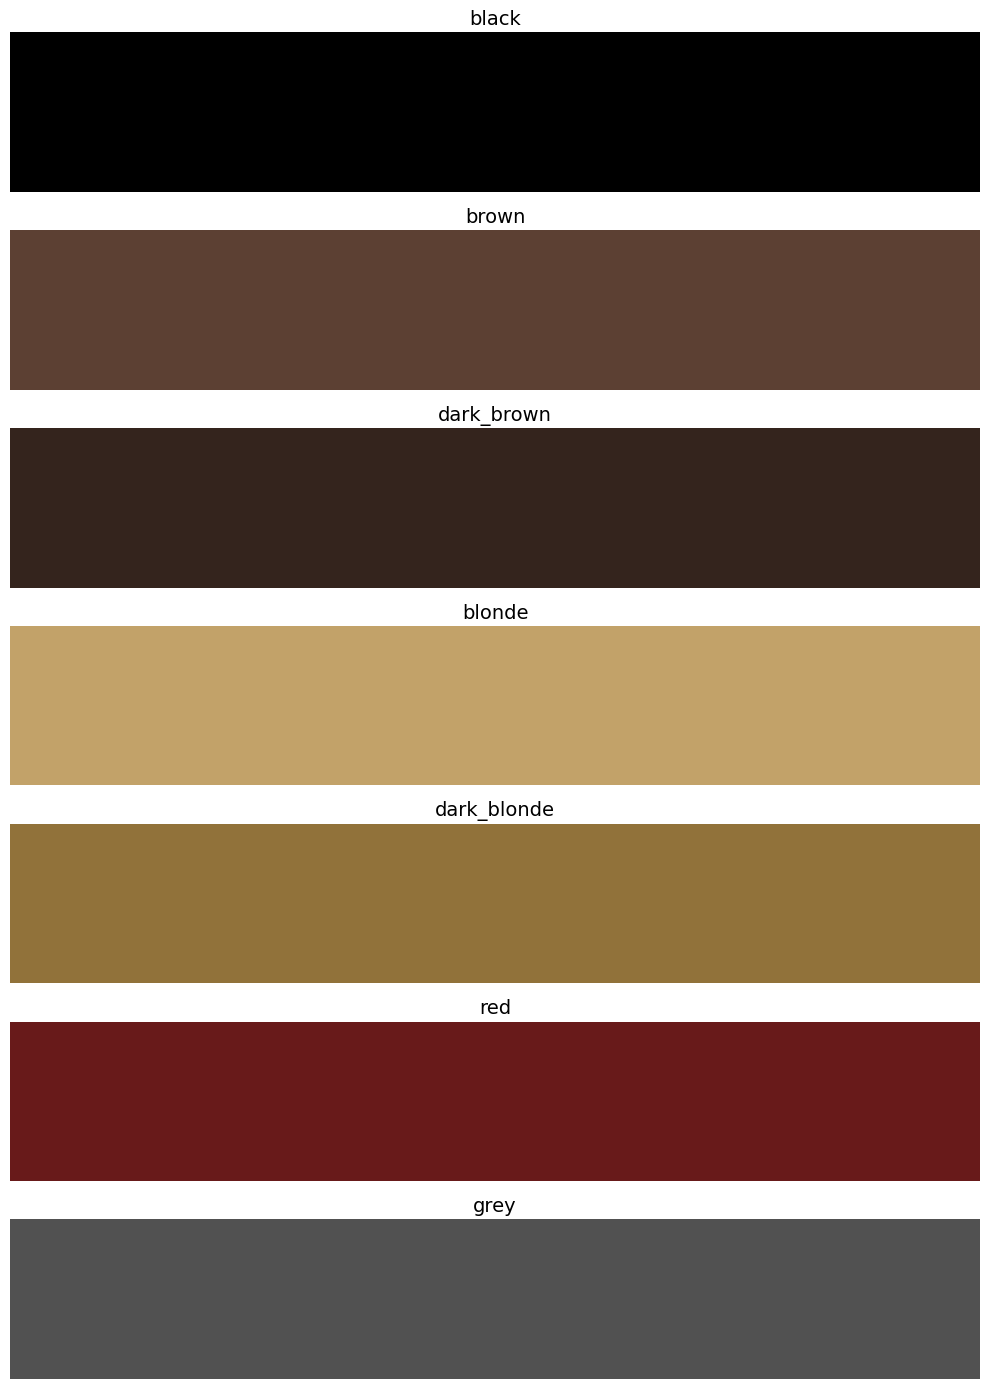

In [ ]:
import matplotlib.pyplot as plt
# Convert hex colors to RGB and plot them
def hex_to_rgb(hex_str):
    """Convert hex color to RGB tuple."""
    hex_str = hex_str.lstrip('#')  # Remove the '#' if present
    return tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4))

# Plot function updated to handle RGB conversion
def plot_colors(color_dict):
    # Define the number of categories
    num_categories = len(color_dict)
    fig, ax = plt.subplots(num_categories, 1, figsize=(10, 2 * num_categories))

    # Iterate through each color category and plot
    for i, (category, colors) in enumerate(color_dict.items()):
        color_list = [hex_to_rgb(color) for color in colors]
        # Normalize the color values to be between 0 and 1 (required for plotting)
        color_list = [(r/255, g/255, b/255) for r, g, b in color_list]
        ax[i].imshow([color_list], aspect="auto")
        ax[i].set_title(category, fontsize=14)
        ax[i].axis("off")  # Disable axis

    plt.tight_layout()
    plt.show()

# Assuming colorSpaces is the dictionary you want to plot
plot_colors(colorSpaces) # Changed colors_dict to colorSpaces

# **Steps to Implement:**
1.   Segment the Hair: Utilize the segmented image you already have.

2.   Extract Pixel Colors: Gather all pixel color data within the segmented hair area.

3.   Calculate Average and Dominant Colors:
*   Average Color: Compute the average RGB values for all hair pixels.
*   Dominant Color: Use a clustering method (like K-means) to find the most frequent color(s).

4.   Color Distance Calculation:
*   Calculate the Euclidean distance between the extracted average and dominant colors and each color category.
*   Find the closest match.



In [ ]:
import facer
import torch

def segment_and_extract_hair(image_path):
    """
    Function to segment the hair from an image and display it with its original colors.

    Parameters:
    - image_path: The path to the input image

    Returns:
    - masked_image: The image with the hair segmented and displayed with its original colors
    """

    # Step 1: Set up the device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Step 2: Load and process the image using facer
    image = facer.hwc2bchw(facer.read_hwc(image_path)).to(device=device)  # image: 1 x 3 x h x w

    # Step 3: Initialize face detector and parser models
    face_detector = facer.face_detector('retinaface/mobilenet', device=device)
    face_parser = facer.face_parser('farl/lapa/448', device=device)

    # Step 4: Perform face detection
    with torch.inference_mode():
        faces = face_detector(image)

    # Step 5: Perform face parsing to get segmentation
    with torch.inference_mode():
        faces = face_parser(image, faces)

    # Step 6: Extract segmentation logits from parsed faces
    seg_logits = faces['seg']['logits']
    seg_probs = seg_logits.softmax(dim=1)  # nfaces x nclasses x h x w

    # Step 7: Extract the hair segment (class 10 corresponds to hair in this segmentation model)
    hair_segment_image = (seg_probs[:, 10, :, :] > 0.5).float() * 255  # Thresholding to get the hair mask

    # Step 8: Create the mask for the hair segment
    hair_mask = (seg_probs[:, 10, :, :] > 0.5).unsqueeze(1)  # Add channel dimension to match the image shape

    # Step 9: Apply the hair mask to the original image to retain the original hair colors
    masked_image = image * hair_mask  # Retain hair colors by applying the mask to the image

    # Step 10: Display the masked image with the original hair colors
    facer.show_bchw(masked_image)  # Display the result using facer

    return masked_image


/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
def hex_to_rgb(hex_color):
    """Convert hex color to RGB tuple."""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def rgb_to_lab(rgb_color):
    """Convert RGB tuple to LAB tuple."""
    rgb_normalized = np.array(rgb_color) / 255.0  # Normalize to 0-1
    lab_color = color.rgb2lab([[rgb_normalized]])[0][0]
    return tuple(lab_color)

def hex_to_lab(hex_color):
    """Convert hex color to LAB tuple."""
    rgb_color = hex_to_rgb(hex_color)
    return rgb_to_lab(rgb_color)

In [ ]:
def extract_hair_colors(masked_image_tensor):
    """Extract all pixel colors from the segmented image."""
    image_np = masked_image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    non_black_pixels = image_np[(image_np[:, :, 0] > 0) | (image_np[:, :, 1] > 0) | (image_np[:, :, 2] > 0)]
    return non_black_pixels

def calculate_average_color(colors):
    """Calculate the average color of a list of RGB tuples."""
    return tuple(np.mean(colors, axis=0).astype(int))

def calculate_dominant_color(colors, n_clusters=3):
    """Use K-means clustering to find the dominant color."""
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(colors)
    dominant_color = kmeans.cluster_centers_[np.argmax(np.bincount(kmeans.labels_))]
    return tuple(dominant_color.astype(int))


In [ ]:
"""     Euclidean Distance
def calculate_color_distance_lab(color1_lab, color2_lab):
    Calculate the Euclidean distance between two LAB colors.
    return distance.euclidean(color1_lab, color2_lab)."""

from skimage.color import deltaE_ciede2000
import numpy as np

def calculate_color_distance_lab(color1_lab, color2_lab):
    """Calculate the CIEDE2000 color difference between two LAB colors."""
    color1 = np.array(color1_lab).reshape(1, 1, 3)
    color2 = np.array(color2_lab).reshape(1, 1, 3)
    return deltaE_ciede2000(color1, color2)[0, 0]


def compare_with_color_sets(avg_color_rgb, dominant_color_rgb, color_spaces):
    """Compare average and dominant colors to predefined color sets in LAB space."""
    avg_color_lab = rgb_to_lab(avg_color_rgb)
    dominant_color_lab = rgb_to_lab(dominant_color_rgb)

    avg_distance_dict = {}
    dominant_distance_dict = {}

    for color_category, color_set in color_spaces.items():
        distances = []
        for hex_color in color_set:
            color_lab = hex_to_lab(hex_color)
            avg_distance = calculate_color_distance_lab(avg_color_lab, color_lab)
            dominant_distance = calculate_color_distance_lab(dominant_color_lab, color_lab)
            distances.append((avg_distance, dominant_distance))

        min_avg_distance = min(distances, key=lambda x: x[0])[0]
        min_dominant_distance = min(distances, key=lambda x: x[1])[1]

        avg_distance_dict[color_category] = min_avg_distance
        dominant_distance_dict[color_category] = min_dominant_distance

    return avg_distance_dict, dominant_distance_dict

In [ ]:
def get_closest_color_category(avg_distance_dict, dominant_distance_dict):
    """Determine the closest color category based on average and dominant distances."""
    combined_distances = {
        category: (avg_distance_dict[category] + dominant_distance_dict[category]) / 2
        for category in avg_distance_dict
    }

    closest_category = min(combined_distances, key=combined_distances.get)
    return closest_category

In [ ]:
# Main Function to Segment and Classify Hair Color
def Classify_hair(image_path, color_spaces):
    """
    Segment the hair from an image, calculate color metrics, and classify.

    Parameters:
    - image_path: Path to the input image.
    - color_spaces: Dictionary of predefined color sets.

    Returns:
    - Closest color classification.
    """
    # Step 1: Segment the hair
    masked_image = segment_and_extract_hair(image_path)

    # Step 2: Extract colors from the segmented image
    hair_colors = extract_hair_colors(masked_image)

    # Step 3: Calculate average and dominant colors
    average_color = calculate_average_color(hair_colors)
    dominant_color = calculate_dominant_color(hair_colors)

    # Step 4: Compare with color sets
    avg_distances, dominant_distances = compare_with_color_sets(average_color, dominant_color, color_spaces)

    # Step 5: Determine the closest color category
    closest_color = get_closest_color_category(avg_distances, dominant_distances)

    # Output the results
    print(f"Average Color (RGB): {average_color}")
    print(f"Dominant Color (RGB): {dominant_color}")
    print("Color Comparison Results:")
    for category in avg_distances:
        print(f"{category} - Avg Distance: {avg_distances[category]}, Dominant Distance: {dominant_distances[category]}")
    print(f"The closest color classification is: {closest_color}")

    return closest_color

# Evaluation

### TEST


In [ ]:
image_path = "/content/test1.jpg"
closest_color = Classify_hair(image_path, colorSpaces)

In [ ]:
import os
import pandas as pd
import zipfile
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Define paths
zip_file_path = '/content/Hair_Data.zip'
extracted_dir = '/content/extracted_Hair_Data'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)
print("Files extracted to:", extracted_dir)


Files extracted to: /content/extracted_Hair_Data


In [ ]:
# Check contents of the extracted directory
print("Contents of extracted directory:")
for folder_name in os.listdir(extracted_dir):
    print("Folder:", folder_name)


Contents of extracted directory:
Folder: Hair_Data


Processing folder: Grey
Processing image: 000078.jpg


Downloading: "https://github.com/elliottzheng/face-detection/releases/download/0.0.1/mobilenet0.25_Final.pth" to /root/.cache/torch/hub/checkpoints/mobilenet0.25_Final.pth
100%|██████████| 1.71M/1.71M [00:00<00:00, 26.5MB/s]
Downloading: "https://github.com/FacePerceiver/facer/releases/download/models-v1/face_parsing.farl.lapa.main_ema_136500_jit191.pt" to /root/.cache/torch/hub/checkpoints/face_parsing.farl.lapa.main_ema_136500_jit191.pt
100%|██████████| 617M/617M [00:07<00:00, 82.2MB/s]


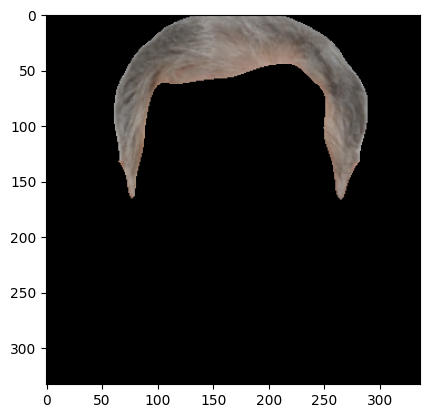

Average Color (RGB): (np.int64(130), np.int64(119), np.int64(111))
Dominant Color (RGB): (np.int64(129), np.int64(118), np.int64(110))
Color Comparison Results:
black - Avg Distance: 37.7763194843749, Dominant Distance: 37.411043273316714
brown - Avg Distance: 20.285432960050734, Dominant Distance: 19.917439153527944
dark_brown - Avg Distance: 28.43062438082355, Dominant Distance: 28.046689039668568
blonde - Avg Distance: 21.60698578749545, Dominant Distance: 21.887879223465564
dark_blonde - Avg Distance: 15.467770812866561, Dominant Distance: 15.445020114347761
red - Avg Distance: 30.68824909769457, Dominant Distance: 30.38313428761266
grey - Avg Distance: 16.17032309162264, Dominant Distance: 15.801638869824982
The closest color classification is: dark_blonde
Processing image: g1.jpg


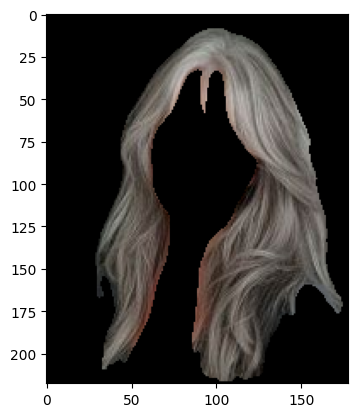

Average Color (RGB): (np.int64(100), np.int64(93), np.int64(87))
Dominant Color (RGB): (np.int64(104), np.int64(96), np.int64(90))
Color Comparison Results:
black - Avg Distance: 28.02065941300855, Dominant Distance: 29.182671323066597
brown - Avg Distance: 13.034824114850716, Dominant Distance: 13.451424599546515
dark_brown - Avg Distance: 19.10307381154947, Dominant Distance: 20.05357926175517
blonde - Avg Distance: 31.507941787008495, Dominant Distance: 30.183047618053017
dark_blonde - Avg Distance: 18.902424359772617, Dominant Distance: 18.30637527932908
red - Avg Distance: 24.955491613128178, Dominant Distance: 25.213078437875488
grey - Avg Distance: 6.52544143815189, Dominant Distance: 7.623376113249563
The closest color classification is: grey
Processing image: 000213.jpg


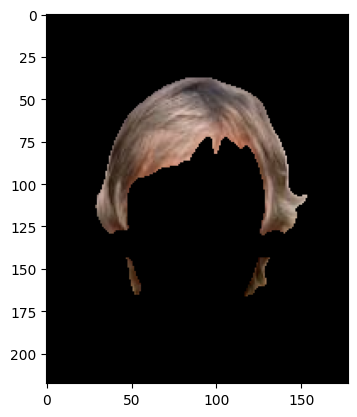

Average Color (RGB): (np.int64(133), np.int64(106), np.int64(93))
Dominant Color (RGB): (np.int64(134), np.int64(107), np.int64(95))
Color Comparison Results:
black - Avg Distance: 36.055961683706656, Dominant Distance: 36.37458984612773
brown - Avg Distance: 14.90863621927999, Dominant Distance: 15.323490842224484
dark_brown - Avg Distance: 24.741680448674835, Dominant Distance: 25.11307911638838
blonde - Avg Distance: 23.837464091524442, Dominant Distance: 23.78790360224808
dark_blonde - Avg Distance: 14.308103905811162, Dominant Distance: 14.728791177159266
red - Avg Distance: 24.489533791984606, Dominant Distance: 24.727186416892142
grey - Avg Distance: 16.758189780227134, Dominant Distance: 16.94948609951662
The closest color classification is: dark_blonde
Processing image: 00099876.jpg


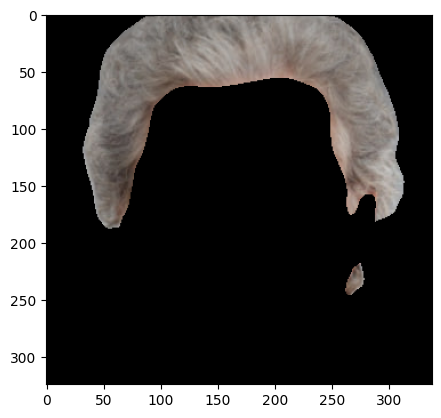

Average Color (RGB): (np.int64(138), np.int64(128), np.int64(122))
Dominant Color (RGB): (np.int64(134), np.int64(125), np.int64(119))
Color Comparison Results:
black - Avg Distance: 40.97656522848358, Dominant Distance: 39.71088427839337
brown - Avg Distance: 23.834957499003753, Dominant Distance: 22.771772621576936
dark_brown - Avg Distance: 31.947624095355714, Dominant Distance: 30.749105527611896
blonde - Avg Distance: 20.123885489830638, Dominant Distance: 20.85200609025241
dark_blonde - Avg Distance: 17.004996479292377, Dominant Distance: 16.736529588770352
red - Avg Distance: 33.57949815467463, Dominant Distance: 32.78541755442789
grey - Avg Distance: 19.36851445300627, Dominant Distance: 17.97097457249403
The closest color classification is: dark_blonde
Processing image: g3.jpg


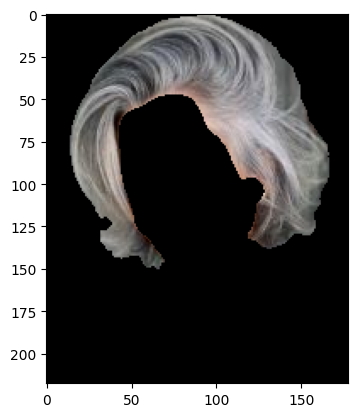

Average Color (RGB): (np.int64(130), np.int64(126), np.int64(124))
Dominant Color (RGB): (np.int64(124), np.int64(121), np.int64(119))
Color Comparison Results:
black - Avg Distance: 39.51093313323355, Dominant Distance: 37.526337361060854
brown - Avg Distance: 23.94261478292096, Dominant Distance: 22.36057705205377
dark_brown - Avg Distance: 31.305913389903935, Dominant Distance: 29.447266683275835
blonde - Avg Distance: 22.47958514805349, Dominant Distance: 23.73843394082071
dark_blonde - Avg Distance: 18.86143016572889, Dominant Distance: 18.679393083122037
red - Avg Distance: 33.82251965479289, Dominant Distance: 32.55156548110998
grey - Avg Distance: 17.45684255406328, Dominant Distance: 15.272716800992042
The closest color classification is: grey
Processing image: 000084.jpg


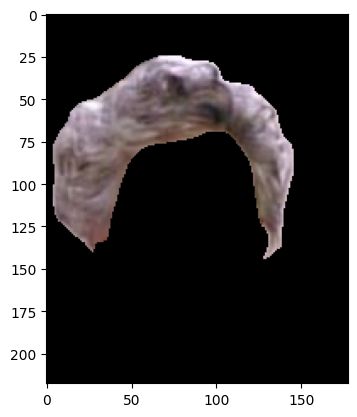

Average Color (RGB): (np.int64(135), np.int64(117), np.int64(120))
Dominant Color (RGB): (np.int64(101), np.int64(81), np.int64(79))
Color Comparison Results:
black - Avg Distance: 38.48568837039061, Dominant Distance: 26.6217129940791
brown - Avg Distance: 20.736758321916657, Dominant Distance: 8.149806193815632
dark_brown - Avg Distance: 28.88048030550531, Dominant Distance: 15.560158283458154
blonde - Avg Distance: 26.781676114118017, Dominant Distance: 36.77888438602617
dark_blonde - Avg Distance: 22.121694515247917, Dominant Distance: 22.961066050762017
red - Avg Distance: 29.297581302254848, Dominant Distance: 18.68210074335579
grey - Avg Distance: 17.580052084620633, Dominant Distance: 10.01133894724965
The closest color classification is: grey
Processing image: 000276.jpg


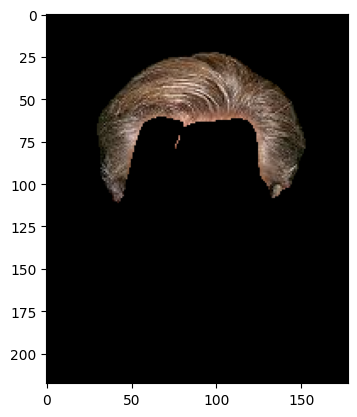

Average Color (RGB): (np.int64(112), np.int64(89), np.int64(73))
Dominant Color (RGB): (np.int64(119), np.int64(94), np.int64(77))
Color Comparison Results:
black - Avg Distance: 29.947151410429807, Dominant Distance: 31.93012930145947
brown - Avg Distance: 8.798979156052894, Dominant Distance: 10.520189101833703
dark_brown - Avg Distance: 18.324093220566354, Dominant Distance: 20.31841160648366
blonde - Avg Distance: 29.94267453450756, Dominant Distance: 27.52220313711049
dark_blonde - Avg Distance: 15.403572115704469, Dominant Distance: 14.070841259495921
red - Avg Distance: 20.819497188613582, Dominant Distance: 21.807570901905493
grey - Avg Distance: 12.811113601599692, Dominant Distance: 14.174342146371202
The closest color classification is: brown
Processing image: g4.jpg


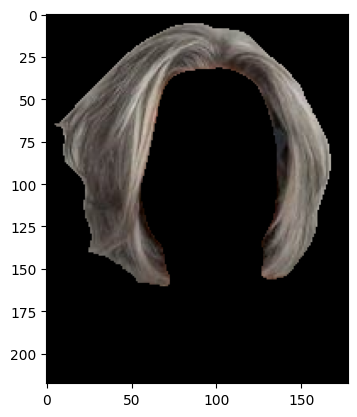

Average Color (RGB): (np.int64(109), np.int64(101), np.int64(94))
Dominant Color (RGB): (np.int64(112), np.int64(104), np.int64(97))
Color Comparison Results:
black - Avg Distance: 30.929342220933183, Dominant Distance: 31.97563405172374
brown - Avg Distance: 14.852469461512525, Dominant Distance: 15.738098852446473
dark_brown - Avg Distance: 21.826365392142968, Dominant Distance: 22.89562536947152
blonde - Avg Distance: 28.01931761380942, Dominant Distance: 26.91837619666669
dark_blonde - Avg Distance: 17.15743428887173, Dominant Distance: 16.78241405226701
red - Avg Distance: 26.49354806045526, Dominant Distance: 27.209565681078523
grey - Avg Distance: 9.226100554009818, Dominant Distance: 10.171788669099215
The closest color classification is: grey
Processing image: 0002456.jpg


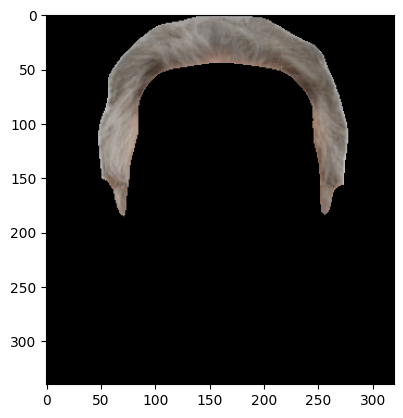

Average Color (RGB): (np.int64(135), np.int64(125), np.int64(116))
Dominant Color (RGB): (np.int64(136), np.int64(125), np.int64(116))
Color Comparison Results:
black - Avg Distance: 39.87228581734051, Dominant Distance: 40.006819334871196
brown - Avg Distance: 22.663235591034343, Dominant Distance: 22.5554894476048
dark_brown - Avg Distance: 30.76383402596471, Dominant Distance: 30.772378560215877
blonde - Avg Distance: 19.781118558525915, Dominant Distance: 19.708425588676942
dark_blonde - Avg Distance: 15.390539949158349, Dominant Distance: 15.36288722607916
red - Avg Distance: 32.901530829268175, Dominant Distance: 32.69161612158258
grey - Avg Distance: 18.31094989705334, Dominant Distance: 18.505287077052078
The closest color classification is: dark_blonde
Processing image: 000221.jpg


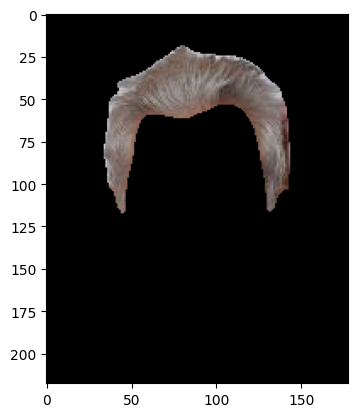

Average Color (RGB): (np.int64(128), np.int64(112), np.int64(106))
Dominant Color (RGB): (np.int64(129), np.int64(112), np.int64(106))
Color Comparison Results:
black - Avg Distance: 36.03680225100614, Dominant Distance: 36.21102368531249
brown - Avg Distance: 17.41298230012794, Dominant Distance: 17.38249497284815
dark_brown - Avg Distance: 25.99208566203867, Dominant Distance: 26.06452354984367
blonde - Avg Distance: 24.190155628582755, Dominant Distance: 24.18461416869288
dark_blonde - Avg Distance: 16.68609760397945, Dominant Distance: 16.753525635190453
red - Avg Distance: 27.463179599166576, Dominant Distance: 27.30567647563412
grey - Avg Distance: 14.910932951065636, Dominant Distance: 15.2013732516992
The closest color classification is: grey
Processing folder: Dark Blonde
Processing image: 000233.jpg


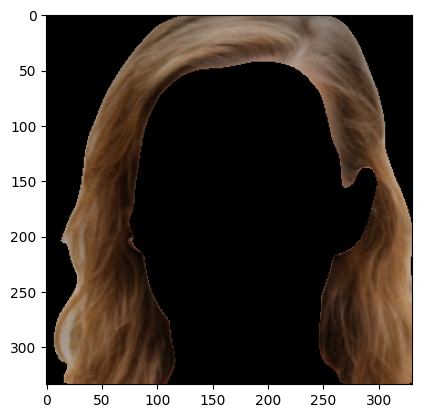

Average Color (RGB): (np.int64(101), np.int64(72), np.int64(51))
Dominant Color (RGB): (np.int64(108), np.int64(74), np.int64(48))
Color Comparison Results:
black - Avg Distance: 26.738210406378727, Dominant Distance: 28.666180703295293
brown - Avg Distance: 4.444458151936103, Dominant Distance: 6.406609094894282
dark_brown - Avg Distance: 14.150508843994372, Dominant Distance: 16.130747371333843
blonde - Avg Distance: 36.54372004782993, Dominant Distance: 34.823715393986106
dark_blonde - Avg Distance: 18.321114558868576, Dominant Distance: 16.828705794724637
red - Avg Distance: 16.768124315452745, Dominant Distance: 17.168179557733826
grey - Avg Distance: 14.93229695516827, Dominant Distance: 16.721938093397174
The closest color classification is: brown
Processing image: 001244.jpg


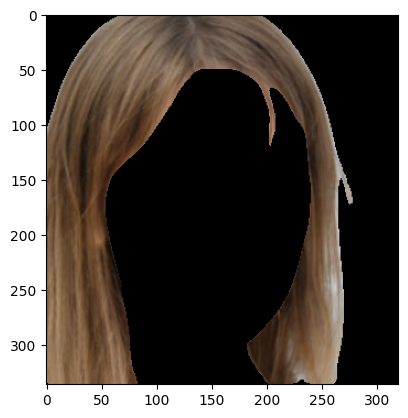

Average Color (RGB): (np.int64(109), np.int64(85), np.int64(65))
Dominant Color (RGB): (np.int64(115), np.int64(89), np.int64(67))
Color Comparison Results:
black - Avg Distance: 29.188037817161256, Dominant Distance: 30.883219411637917
brown - Avg Distance: 8.069373912330716, Dominant Distance: 9.508886677727626
dark_brown - Avg Distance: 17.443726160922154, Dominant Distance: 19.15375891379582
blonde - Avg Distance: 31.098660360657437, Dominant Distance: 28.892199151364444
dark_blonde - Avg Distance: 15.096369996724292, Dominant Distance: 13.558641819047528
red - Avg Distance: 20.426084058867936, Dominant Distance: 21.263602887851075
grey - Avg Distance: 13.441466854640066, Dominant Distance: 14.599720103524904
The closest color classification is: brown
Processing image: 00002333.jpg


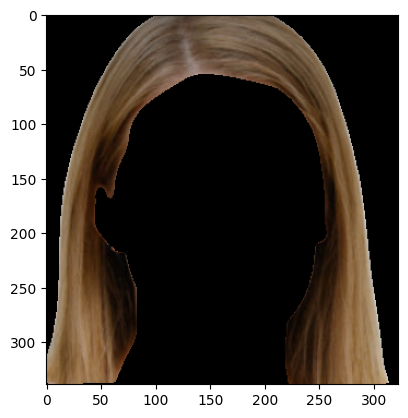

Average Color (RGB): (np.int64(104), np.int64(78), np.int64(53))
Dominant Color (RGB): (np.int64(109), np.int64(81), np.int64(54))
Color Comparison Results:
black - Avg Distance: 28.00195658400286, Dominant Distance: 29.36234945832952
brown - Avg Distance: 7.318973399948814, Dominant Distance: 8.327266545051044
dark_brown - Avg Distance: 16.12229422954913, Dominant Distance: 17.486775689030797
blonde - Avg Distance: 33.69966699728211, Dominant Distance: 31.958083621064528
dark_blonde - Avg Distance: 15.786199569830957, Dominant Distance: 14.528465747732223
red - Avg Distance: 19.61124067815306, Dominant Distance: 20.141255264498653
grey - Avg Distance: 14.703814823995833, Dominant Distance: 15.509517072016546
The closest color classification is: brown
Processing image: 0009988.jpg


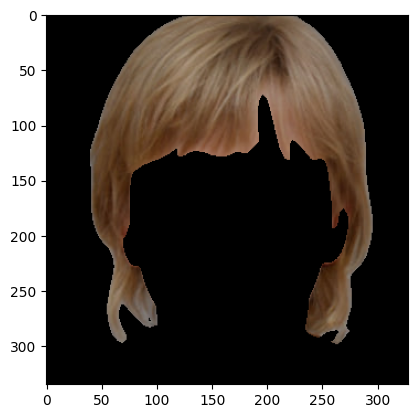

Average Color (RGB): (np.int64(116), np.int64(88), np.int64(64))
Dominant Color (RGB): (np.int64(139), np.int64(114), np.int64(93))
Color Comparison Results:
black - Avg Distance: 31.104188318959757, Dominant Distance: 38.621411581023416
brown - Avg Distance: 9.493219080084922, Dominant Distance: 18.222303166061113
dark_brown - Avg Distance: 19.25289820901539, Dominant Distance: 27.764575093215623
blonde - Avg Distance: 28.97551262678664, Dominant Distance: 19.243228673808254
dark_blonde - Avg Distance: 13.304762735810437, Dominant Distance: 10.198715838648157
red - Avg Distance: 21.00312553385247, Dominant Distance: 28.26846243742153
grey - Avg Distance: 15.338025415100565, Dominant Distance: 19.032189452208733
The closest color classification is: dark_blonde
Processing image: 000063.jpg


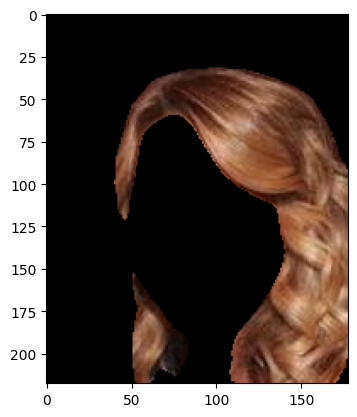

Average Color (RGB): (np.int64(128), np.int64(81), np.int64(57))
Dominant Color (RGB): (np.int64(136), np.int64(84), np.int64(58))
Color Comparison Results:
black - Avg Distance: 32.970663706199105, Dominant Distance: 34.771416858830094
brown - Avg Distance: 9.67764115214478, Dominant Distance: 11.648649854562361
dark_brown - Avg Distance: 20.27494677048978, Dominant Distance: 22.192273267439358
blonde - Avg Distance: 31.079107190332905, Dominant Distance: 29.375318940588222
dark_blonde - Avg Distance: 16.403775420756492, Dominant Distance: 15.794842730552269
red - Avg Distance: 16.67606837233567, Dominant Distance: 17.681260429647647
grey - Avg Distance: 19.331405889998795, Dominant Distance: 20.632428603029393
The closest color classification is: brown
Processing image: 00066.jpg


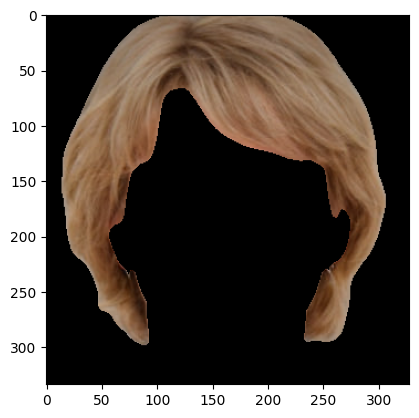

Average Color (RGB): (np.int64(138), np.int64(103), np.int64(76))
Dominant Color (RGB): (np.int64(157), np.int64(125), np.int64(98))
Color Comparison Results:
black - Avg Distance: 37.06245746478272, Dominant Distance: 43.826654287939455
brown - Avg Distance: 15.146350077470425, Dominant Distance: 23.290019771804612
dark_brown - Avg Distance: 25.354278417164892, Dominant Distance: 33.004842477768456
blonde - Avg Distance: 22.009591336290157, Dominant Distance: 14.56373908481498
dark_blonde - Avg Distance: 9.803729057459778, Dominant Distance: 9.940556632902975
red - Avg Distance: 24.563780453297408, Dominant Distance: 32.09089582110988
grey - Avg Distance: 19.448999757206224, Dominant Distance: 24.441844392643347
The closest color classification is: dark_blonde
Processing image: 000105.jpg


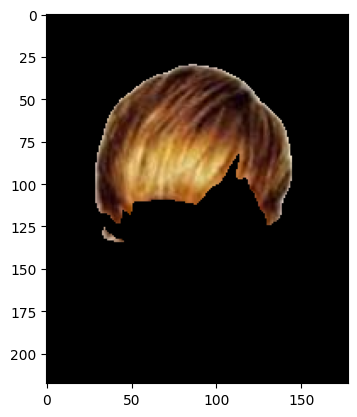

Average Color (RGB): (np.int64(130), np.int64(86), np.int64(49))
Dominant Color (RGB): (np.int64(75), np.int64(36), np.int64(21))
Color Comparison Results:
black - Avg Distance: 34.300424185029904, Dominant Distance: 21.75523948964858
brown - Avg Distance: 12.30575587531014, Dominant Distance: 9.16556854963132
dark_brown - Avg Distance: 22.220257389971344, Dominant Distance: 9.507360485692864
blonde - Avg Distance: 27.858226574405997, Dominant Distance: 48.04607878836957
dark_blonde - Avg Distance: 12.14679475698226, Dominant Distance: 29.227752906337233
red - Avg Distance: 20.842630860906894, Dominant Distance: 9.577435591748223
grey - Avg Distance: 20.224088200934165, Dominant Distance: 21.370259322692064
The closest color classification is: brown
Processing image: 00007778.jpg


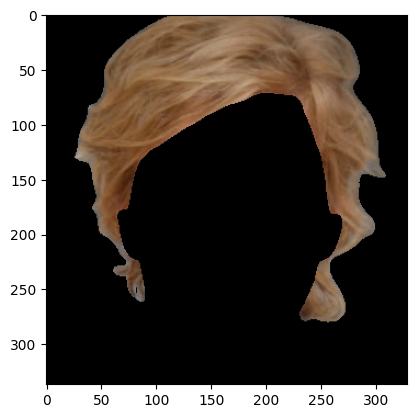

Average Color (RGB): (np.int64(133), np.int64(99), np.int64(70))
Dominant Color (RGB): (np.int64(133), np.int64(99), np.int64(71))
Color Comparison Results:
black - Avg Distance: 35.7561214056166, Dominant Distance: 35.70420083789457
brown - Avg Distance: 13.956794013048992, Dominant Distance: 13.817289327783937
dark_brown - Avg Distance: 24.0391086985332, Dominant Distance: 23.950770676739985
blonde - Avg Distance: 23.367009550154812, Dominant Distance: 23.481670264287555
dark_blonde - Avg Distance: 9.705450100041206, Dominant Distance: 10.009705200399221
red - Avg Distance: 23.85391787995906, Dominant Distance: 23.671317593731242
grey - Avg Distance: 18.7492316603385, Dominant Distance: 18.63126047047781
The closest color classification is: dark_blonde
Processing image: 000100.jpg


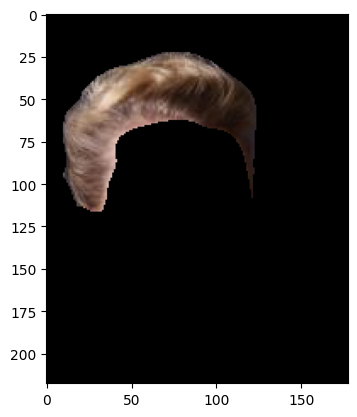

Average Color (RGB): (np.int64(115), np.int64(90), np.int64(78))
Dominant Color (RGB): (np.int64(123), np.int64(95), np.int64(82))
Color Comparison Results:
black - Avg Distance: 30.512072540251502, Dominant Distance: 32.71244112606003
brown - Avg Distance: 8.910560416956859, Dominant Distance: 10.837349959752304
dark_brown - Avg Distance: 18.742691312553127, Dominant Distance: 20.922947368742847
blonde - Avg Distance: 30.18280716769376, Dominant Distance: 27.83344906256027
dark_blonde - Avg Distance: 16.833886203461358, Dominant Distance: 15.726884741272004
red - Avg Distance: 20.052540741965842, Dominant Distance: 21.026379992425515
grey - Avg Distance: 13.06671481647246, Dominant Distance: 14.817213079496117
The closest color classification is: brown
Processing image: 000001.jpg


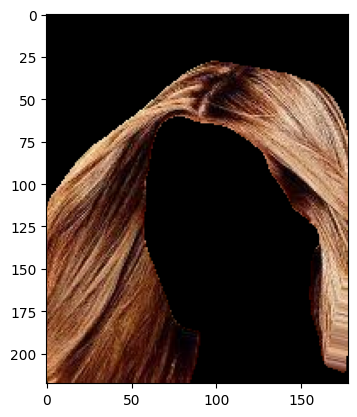

Average Color (RGB): (np.int64(129), np.int64(83), np.int64(60))
Dominant Color (RGB): (np.int64(62), np.int64(22), np.int64(12))
Color Comparison Results:
black - Avg Distance: 33.26099520263979, Dominant Distance: 20.141808671245936
brown - Avg Distance: 9.916704961378239, Dominant Distance: 13.14057467509763
dark_brown - Avg Distance: 20.59677867698791, Dominant Distance: 9.96807233219555
blonde - Avg Distance: 30.390766495432832, Dominant Distance: 52.082100696752434
dark_blonde - Avg Distance: 16.133231403578964, Dominant Distance: 33.87358737667745
red - Avg Distance: 17.11709811649795, Dominant Distance: 9.826194857268206
grey - Avg Distance: 19.147685574597855, Dominant Distance: 23.89551023755228
The closest color classification is: brown
Processing folder: Dark Brown
Processing image: 000078.jpg


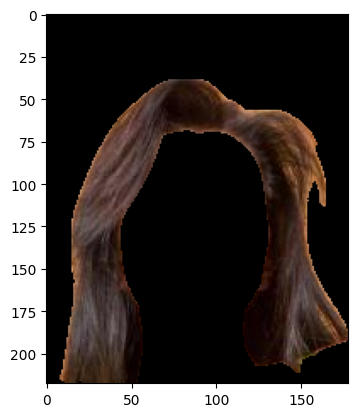

Average Color (RGB): (np.int64(74), np.int64(49), np.int64(39))
Dominant Color (RGB): (np.int64(80), np.int64(56), np.int64(47))
Color Comparison Results:
black - Avg Distance: 19.573265069619815, Dominant Distance: 20.78949025844447
brown - Avg Distance: 5.247817858057297, Dominant Distance: 3.5583769795775275
dark_brown - Avg Distance: 6.066831495384629, Dominant Distance: 7.614148455206327
blonde - Avg Distance: 45.86083345385153, Dominant Distance: 44.1552668712054
dark_blonde - Avg Distance: 27.154118042511758, Dominant Distance: 25.70553112667352
red - Avg Distance: 13.1951719466461, Dominant Distance: 13.836823788172156
grey - Avg Distance: 15.678537030986506, Dominant Distance: 13.961319784383145
The closest color classification is: brown
Processing image: 000026.jpg


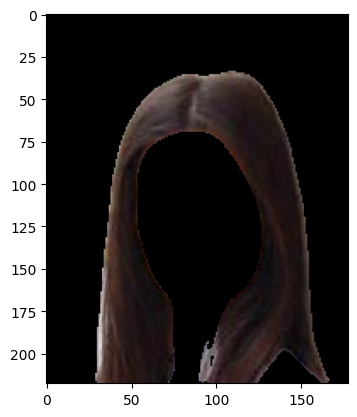

Average Color (RGB): (np.int64(51), np.int64(37), np.int64(36))
Dominant Color (RGB): (np.int64(33), np.int64(21), np.int64(21))
Color Comparison Results:
black - Avg Distance: 12.99915973542354, Dominant Distance: 9.230112575294894
brown - Avg Distance: 12.18803756690955, Dominant Distance: 16.90274958593811
dark_brown - Avg Distance: 3.702968327002378, Dominant Distance: 6.585809222248308
blonde - Avg Distance: 51.03110903964387, Dominant Distance: 55.253417296522926
dark_blonde - Avg Distance: 33.29011104103979, Dominant Distance: 37.702531111229895
red - Avg Distance: 17.50792521073667, Dominant Distance: 19.95058009533149
grey - Avg Distance: 15.692904712441008, Dominant Distance: 19.988087571240012
The closest color classification is: dark_brown
Processing image: 000142.jpg


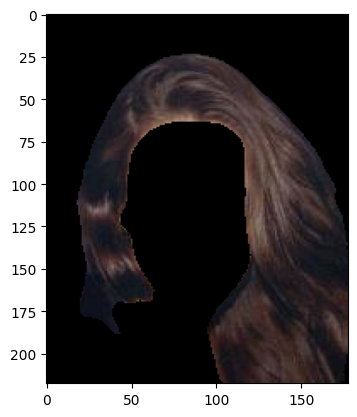

Average Color (RGB): (np.int64(54), np.int64(43), np.int64(45))
Dominant Color (RGB): (np.int64(32), np.int64(27), np.int64(32))
Color Comparison Results:
black - Avg Distance: 13.615740464460785, Dominant Distance: 8.24735498203108
brown - Avg Distance: 12.620462006639919, Dominant Distance: 18.67480583294293
dark_brown - Avg Distance: 6.206954556266949, Dominant Distance: 9.615328586082251
blonde - Avg Distance: 50.47873238838265, Dominant Distance: 55.520831926518184
dark_blonde - Avg Distance: 33.22524347403977, Dominant Distance: 38.65543561336042
red - Avg Distance: 18.896481941944245, Dominant Distance: 22.973526565587804
grey - Avg Distance: 13.551478357720804, Dominant Distance: 17.81599094437747
The closest color classification is: dark_brown
Processing image: 000034.jpg


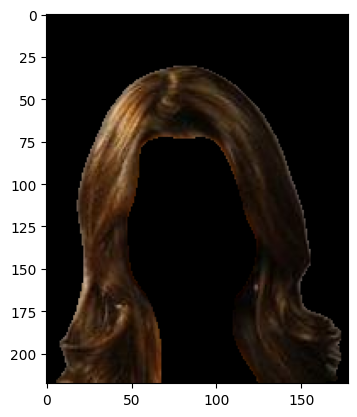

Average Color (RGB): (np.int64(54), np.int64(35), np.int64(21))
Dominant Color (RGB): (np.int64(32), np.int64(18), np.int64(9))
Color Comparison Results:
black - Avg Distance: 15.527170165451334, Dominant Distance: 9.617494376907777
brown - Avg Distance: 10.638496767134114, Dominant Distance: 16.55630340270956
dark_brown - Avg Distance: 3.7969755949772668, Dominant Distance: 5.8224550870896605
blonde - Avg Distance: 49.039565239096476, Dominant Distance: 54.58316621700289
dark_blonde - Avg Distance: 29.908208467439408, Dominant Distance: 36.40413203503743
red - Avg Distance: 16.658701269314268, Dominant Distance: 19.773832447273872
grey - Avg Distance: 18.33422996142752, Dominant Distance: 21.114436102282756
The closest color classification is: dark_brown
Processing image: 00333.jpg


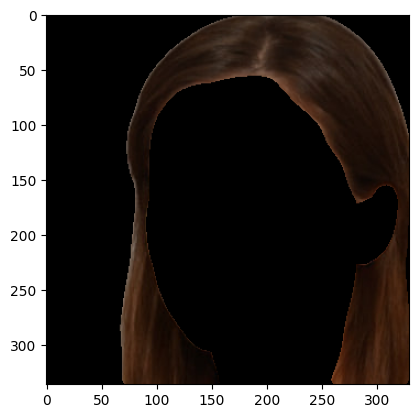

Average Color (RGB): (np.int64(49), np.int64(29), np.int64(18))
Dominant Color (RGB): (np.int64(34), np.int64(18), np.int64(9))
Color Comparison Results:
black - Avg Distance: 14.564078023254416, Dominant Distance: 10.70309073164379
brown - Avg Distance: 11.942833589980694, Dominant Distance: 16.092763942066917
dark_brown - Avg Distance: 3.408787669932886, Dominant Distance: 5.6128327483291445
blonde - Avg Distance: 50.904519707397284, Dominant Distance: 54.54183174816325
dark_blonde - Avg Distance: 32.13440926021028, Dominant Distance: 36.37376886858634
red - Avg Distance: 16.005942198737568, Dominant Distance: 18.755697263551465
grey - Avg Distance: 19.65501387766221, Dominant Distance: 21.437774584235278
The closest color classification is: dark_brown
Processing image: 000043.jpg


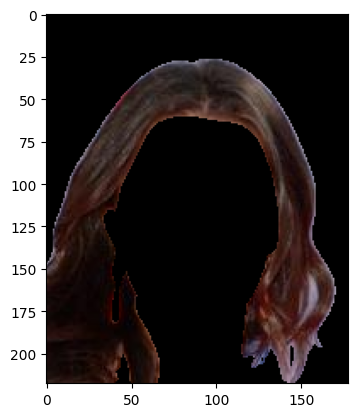

Average Color (RGB): (np.int64(56), np.int64(35), np.int64(33))
Dominant Color (RGB): (np.int64(30), np.int64(12), np.int64(9))
Color Comparison Results:
black - Avg Distance: 15.267004769428397, Dominant Distance: 9.931332003078566
brown - Avg Distance: 11.154544688393639, Dominant Distance: 17.956251199419427
dark_brown - Avg Distance: 4.18366563043511, Dominant Distance: 7.68076191092953
blonde - Avg Distance: 51.05435446677261, Dominant Distance: 56.51852392108445
dark_blonde - Avg Distance: 33.23422703548142, Dominant Distance: 38.87680840466323
red - Avg Distance: 14.739131794683693, Dominant Distance: 19.64260705078105
grey - Avg Distance: 17.624858610181835, Dominant Distance: 22.402656193389728
The closest color classification is: dark_brown
Processing image: 000259.jpg


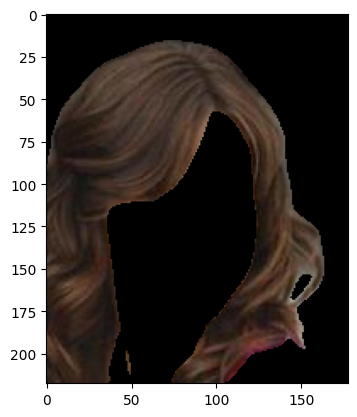

Average Color (RGB): (np.int64(66), np.int64(48), np.int64(39))
Dominant Color (RGB): (np.int64(45), np.int64(31), np.int64(24))
Color Comparison Results:
black - Avg Distance: 17.134772443367794, Dominant Distance: 12.043939874590793
brown - Avg Distance: 7.111898139336168, Dominant Distance: 12.769992462217129
dark_brown - Avg Distance: 4.039581353311879, Dominant Distance: 1.9587335019740344
blonde - Avg Distance: 46.47973201151841, Dominant Distance: 51.20748376989607
dark_blonde - Avg Distance: 27.738296223369105, Dominant Distance: 32.73780472654644
red - Avg Distance: 15.831470828449463, Dominant Distance: 18.02839774090109
grey - Avg Distance: 14.160321472757653, Dominant Distance: 17.722273777714847
The closest color classification is: dark_brown
Processing image: 000180.jpg


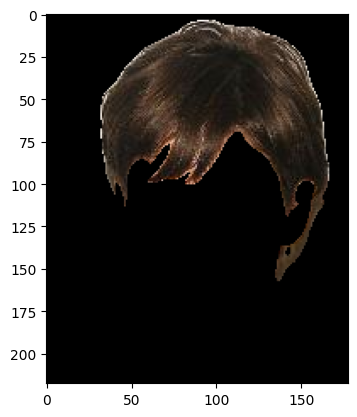

Average Color (RGB): (np.int64(62), np.int64(49), np.int64(38))
Dominant Color (RGB): (np.int64(40), np.int64(31), np.int64(23))
Color Comparison Results:
black - Avg Distance: 16.133915884808605, Dominant Distance: 10.325503641038953
brown - Avg Distance: 8.996550650690892, Dominant Distance: 14.543804189105835
dark_brown - Avg Distance: 5.156450397980903, Dominant Distance: 4.787847691126711
blonde - Avg Distance: 46.12059952824265, Dominant Distance: 51.287204600197335
dark_blonde - Avg Distance: 27.137531202546793, Dominant Distance: 32.76268985718188
red - Avg Distance: 18.60241071148763, Dominant Distance: 20.846681320177222
grey - Avg Distance: 13.197391860378902, Dominant Distance: 17.20916842284413
The closest color classification is: dark_brown
Processing image: 000098.jpg
Error processing /content/extracted_Hair_Data/Hair_Data/Dark Brown/000098.jpg: 
Processing image: 000172.jpg


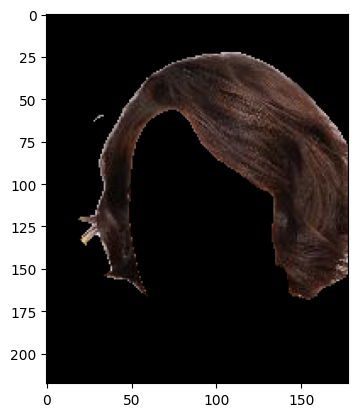

Average Color (RGB): (np.int64(64), np.int64(45), np.int64(39))
Dominant Color (RGB): (np.int64(44), np.int64(28), np.int64(23))
Color Comparison Results:
black - Avg Distance: 16.601313513065385, Dominant Distance: 12.202145101490748
brown - Avg Distance: 7.94948558177056, Dominant Distance: 13.257281500766068
dark_brown - Avg Distance: 3.4626083426929735, Dominant Distance: 2.7394010915025615
blonde - Avg Distance: 47.77748369494777, Dominant Distance: 52.24784977625519
dark_blonde - Avg Distance: 29.42365413353145, Dominant Distance: 34.03074152695074
red - Avg Distance: 15.083620954779152, Dominant Distance: 17.204578036258557
grey - Avg Distance: 14.832367166541971, Dominant Distance: 18.732526535610308
The closest color classification is: dark_brown
Processing folder: Brown
Processing image: 000116.jpg


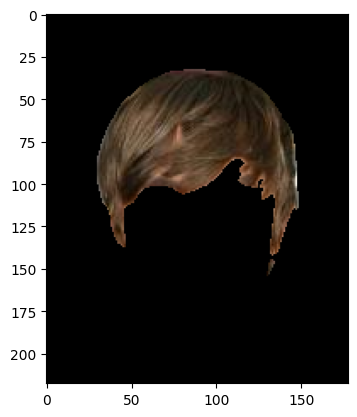

Average Color (RGB): (np.int64(79), np.int64(59), np.int64(41))
Dominant Color (RGB): (np.int64(50), np.int64(37), np.int64(22))
Color Comparison Results:
black - Avg Distance: 21.18424065490095, Dominant Distance: 14.203616182601456
brown - Avg Distance: 5.5882384405975305, Dominant Distance: 12.297259695516788
dark_brown - Avg Distance: 9.105796886428179, Dominant Distance: 5.386685119666434
blonde - Avg Distance: 42.17236093512871, Dominant Distance: 48.73852519019857
dark_blonde - Avg Distance: 22.621541849055827, Dominant Distance: 29.542544925574738
red - Avg Distance: 17.435312394974943, Dominant Distance: 19.819373071679255
grey - Avg Distance: 13.802046640784614, Dominant Distance: 17.141278132504112
The closest color classification is: dark_brown
Processing image: 000163.jpg


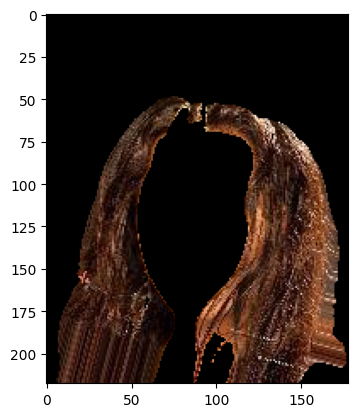

Average Color (RGB): (np.int64(82), np.int64(47), np.int64(32))
Dominant Color (RGB): (np.int64(47), np.int64(19), np.int64(10))
Color Comparison Results:
black - Avg Distance: 22.360286812725064, Dominant Distance: 16.07504448952449
brown - Avg Distance: 5.759887681285976, Dominant Distance: 14.343725960079595
dark_brown - Avg Distance: 9.178307187438893, Dominant Distance: 7.342177113869607
blonde - Avg Distance: 45.38466847402008, Dominant Distance: 53.71236205002751
dark_blonde - Avg Distance: 26.43337847194926, Dominant Distance: 35.55667537452464
red - Avg Distance: 10.695593164922334, Dominant Distance: 13.84773712872888
grey - Avg Distance: 18.651464828490425, Dominant Distance: 23.031927435957506
The closest color classification is: dark_brown
Processing image: 00004454.jpg


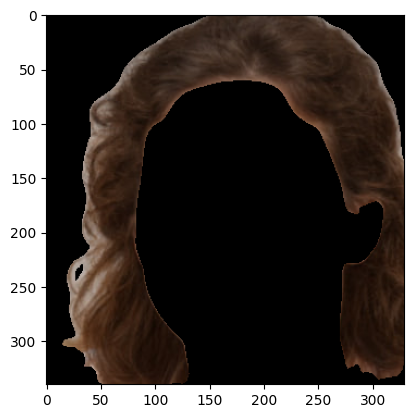

Average Color (RGB): (np.int64(65), np.int64(44), np.int64(32))
Dominant Color (RGB): (np.int64(46), np.int64(27), np.int64(17))
Color Comparison Results:
black - Avg Distance: 17.489030214693887, Dominant Distance: 13.76259545677762
brown - Avg Distance: 7.4244381910684405, Dominant Distance: 12.696561828716277
dark_brown - Avg Distance: 4.093319855298401, Dominant Distance: 3.3938363211809603
blonde - Avg Distance: 46.95336852614324, Dominant Distance: 51.60447083932405
dark_blonde - Avg Distance: 27.923450300875242, Dominant Distance: 32.96039975176787
red - Avg Distance: 15.05856294972323, Dominant Distance: 16.454453866796477
grey - Avg Distance: 16.151501441555368, Dominant Distance: 19.89535453322522
The closest color classification is: dark_brown
Processing image: 000222.jpg


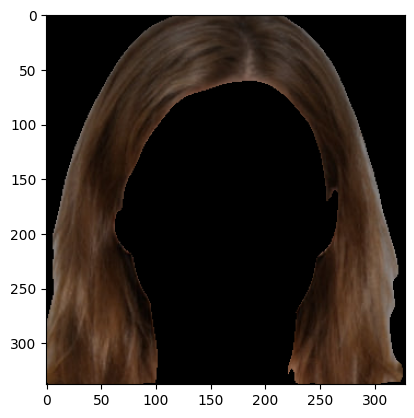

Average Color (RGB): (np.int64(71), np.int64(49), np.int64(35))
Dominant Color (RGB): (np.int64(77), np.int64(53), np.int64(37))
Color Comparison Results:
black - Avg Distance: 19.010074345665913, Dominant Distance: 20.616307782230148
brown - Avg Distance: 5.954069442278334, Dominant Distance: 4.702438201361595
dark_brown - Avg Distance: 5.835673852845888, Dominant Distance: 7.5430269941903925
blonde - Avg Distance: 45.350431533606205, Dominant Distance: 43.95154635131009
dark_blonde - Avg Distance: 26.118539653368423, Dominant Distance: 24.577158170290485
red - Avg Distance: 15.110976200367244, Dominant Distance: 14.94003244038142
grey - Avg Distance: 15.49898752671953, Dominant Distance: 15.40979601538294
The closest color classification is: brown
Processing image: 000236.jpg


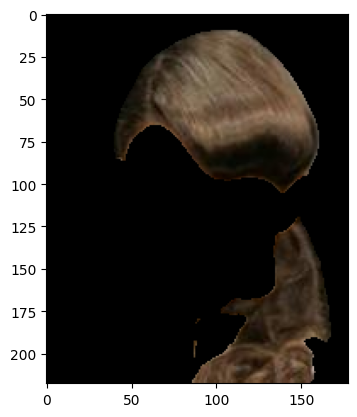

Average Color (RGB): (np.int64(78), np.int64(61), np.int64(44))
Dominant Color (RGB): (np.int64(36), np.int64(26), np.int64(14))
Color Comparison Results:
black - Avg Distance: 20.8749229276463, Dominant Distance: 10.321993233863854
brown - Avg Distance: 6.50557856802717, Dominant Distance: 15.704605278920459
dark_brown - Avg Distance: 9.432867527056812, Dominant Distance: 6.03044694755838
blonde - Avg Distance: 41.8420146588545, Dominant Distance: 52.119987284680235
dark_blonde - Avg Distance: 22.424473674001195, Dominant Distance: 33.44580564302112
red - Avg Distance: 18.62132830096433, Dominant Distance: 21.458948351164153
grey - Avg Distance: 12.615648410812293, Dominant Distance: 19.148092569308734
The closest color classification is: dark_brown
Processing image: 003456.jpg


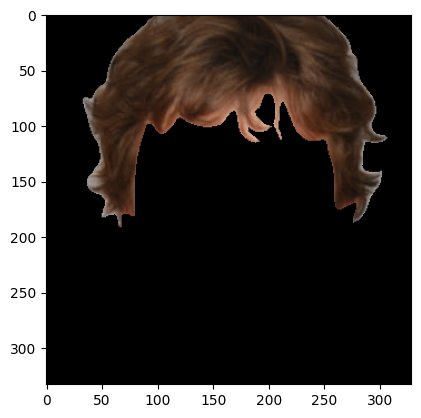

Average Color (RGB): (np.int64(77), np.int64(52), np.int64(38))
Dominant Color (RGB): (np.int64(54), np.int64(35), np.int64(23))
Color Comparison Results:
black - Avg Distance: 20.495023768186023, Dominant Distance: 15.231034687994072
brown - Avg Distance: 4.382239141652792, Dominant Distance: 10.457865031335889
dark_brown - Avg Distance: 7.150079433494086, Dominant Distance: 2.872822483791528
blonde - Avg Distance: 44.44985720368615, Dominant Distance: 49.28573066033955
dark_blonde - Avg Distance: 25.305299983501037, Dominant Distance: 30.31900523970984
red - Avg Distance: 14.046584023526416, Dominant Distance: 16.233758929927546
grey - Avg Distance: 15.538525349344223, Dominant Distance: 18.05039390175425
The closest color classification is: dark_brown
Processing image: 0076778.jpg


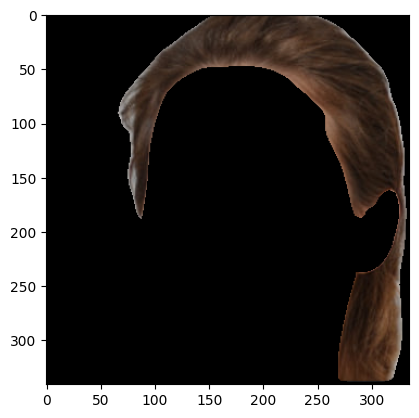

Average Color (RGB): (np.int64(74), np.int64(53), np.int64(41))
Dominant Color (RGB): (np.int64(54), np.int64(36), np.int64(26))
Color Comparison Results:
black - Avg Distance: 19.41919127540638, Dominant Distance: 14.78552261415095
brown - Avg Distance: 4.945741338835474, Dominant Distance: 10.330646676404132
dark_brown - Avg Distance: 6.306383144834554, Dominant Distance: 1.779948827815061
blonde - Avg Distance: 44.58340186656747, Dominant Distance: 49.35334200379404
dark_blonde - Avg Distance: 25.576667349276274, Dominant Distance: 30.552614728221265
red - Avg Distance: 15.244087491888967, Dominant Distance: 16.26335283755786
grey - Avg Distance: 14.133229865535181, Dominant Distance: 17.351964811072925
The closest color classification is: dark_brown
Processing image: 000083.jpg


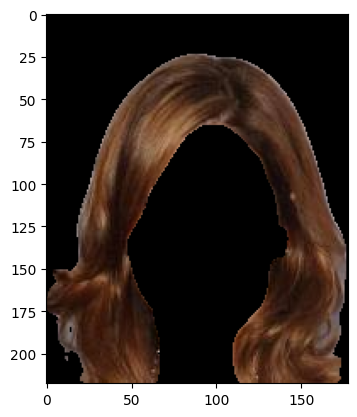

Average Color (RGB): (np.int64(82), np.int64(51), np.int64(35))
Dominant Color (RGB): (np.int64(53), np.int64(27), np.int64(16))
Color Comparison Results:
black - Avg Distance: 22.09853259418923, Dominant Distance: 16.469467171966716
brown - Avg Distance: 4.440222698575429, Dominant Distance: 11.844150951760204
dark_brown - Avg Distance: 8.768334773605487, Dominant Distance: 5.4446142352957505
blonde - Avg Distance: 44.291336035442, Dominant Distance: 51.24188827325538
dark_blonde - Avg Distance: 25.12527052651925, Dominant Distance: 32.60038227300046
red - Avg Distance: 12.362238641337695, Dominant Distance: 13.760358740871933
grey - Avg Distance: 17.265538621008044, Dominant Distance: 21.093789564228917
The closest color classification is: dark_brown
Processing image: 000107.jpg


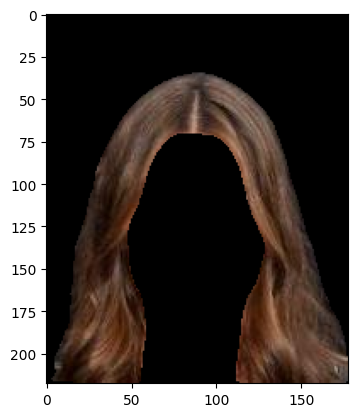

Average Color (RGB): (np.int64(85), np.int64(58), np.int64(43))
Dominant Color (RGB): (np.int64(90), np.int64(62), np.int64(46))
Color Comparison Results:
black - Avg Distance: 22.4353067120484, Dominant Distance: 23.688780790614597
brown - Avg Distance: 2.4022779367329674, Dominant Distance: 1.6429708606708884
dark_brown - Avg Distance: 9.213129734499327, Dominant Distance: 10.589398425850693
blonde - Avg Distance: 42.52495573177839, Dominant Distance: 41.07090248178303
dark_blonde - Avg Distance: 23.48718416513996, Dominant Distance: 22.19363436208921
red - Avg Distance: 14.01045454677911, Dominant Distance: 14.362036728111086
grey - Avg Distance: 15.08128824720018, Dominant Distance: 14.886039494062755
The closest color classification is: brown
Processing image: 0002345.jpg


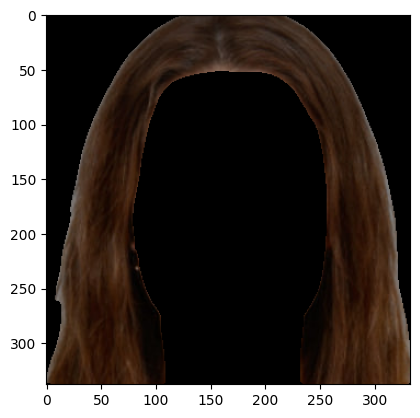

Average Color (RGB): (np.int64(56), np.int64(34), np.int64(21))
Dominant Color (RGB): (np.int64(64), np.int64(39), np.int64(23))
Color Comparison Results:
black - Avg Distance: 16.24052642610488, Dominant Distance: 18.301242759417185
brown - Avg Distance: 10.222629771959747, Dominant Distance: 8.561707072771943
dark_brown - Avg Distance: 3.928080263434185, Dominant Distance: 5.617084380919126
blonde - Avg Distance: 49.305833520002004, Dominant Distance: 47.60318680519069
dark_blonde - Avg Distance: 30.29658965624377, Dominant Distance: 28.3233910578803
red - Avg Distance: 15.174264411780332, Dominant Distance: 14.377165897468798
grey - Avg Distance: 18.9487322715791, Dominant Distance: 18.61973146264134
The closest color classification is: dark_brown
Processing folder: Red
Processing image: 000174.jpg


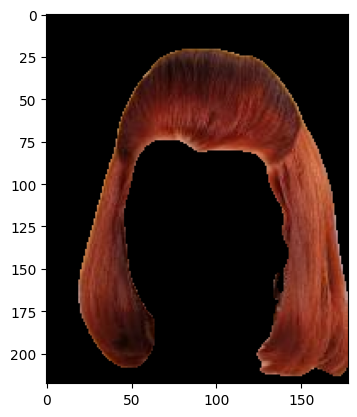

Average Color (RGB): (np.int64(120), np.int64(48), np.int64(33))
Dominant Color (RGB): (np.int64(130), np.int64(48), np.int64(33))
Color Comparison Results:
black - Avg Distance: 30.138884783469123, Dominant Distance: 31.65745736600427
brown - Avg Distance: 11.353499402176825, Dominant Distance: 12.886474713402947
dark_brown - Avg Distance: 18.04413091508368, Dominant Distance: 19.86371507842239
blonde - Avg Distance: 43.43727087223309, Dominant Distance: 42.61772761305505
dark_blonde - Avg Distance: 26.728978242385818, Dominant Distance: 26.853779461065727
red - Avg Distance: 6.760952929207274, Dominant Distance: 7.897119294452715
grey - Avg Distance: 23.094530962007124, Dominant Distance: 23.74352838959394
The closest color classification is: red
Processing image: 000150.jpg


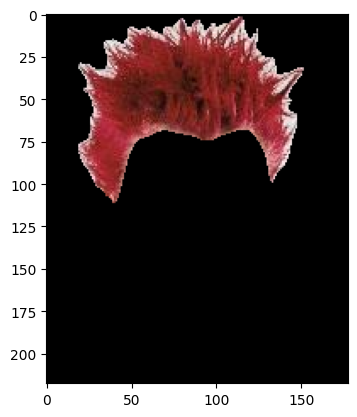

Average Color (RGB): (np.int64(149), np.int64(68), np.int64(67))
Dominant Color (RGB): (np.int64(123), np.int64(35), np.int64(32))
Color Comparison Results:
black - Avg Distance: 35.69542040081425, Dominant Distance: 30.16742390748027
brown - Avg Distance: 15.42659008339831, Dominant Distance: 14.0454866762143
dark_brown - Avg Distance: 23.889133012033348, Dominant Distance: 19.06104338010163
blonde - Avg Distance: 37.766914677121136, Dominant Distance: 46.882059549763646
dark_blonde - Avg Distance: 27.10049324661754, Dominant Distance: 30.901555932819452
red - Avg Distance: 13.177866981667332, Dominant Distance: 4.267947918610872
grey - Avg Distance: 23.46363549923753, Dominant Distance: 24.449725175873468
The closest color classification is: red
Processing image: 000002.jpg


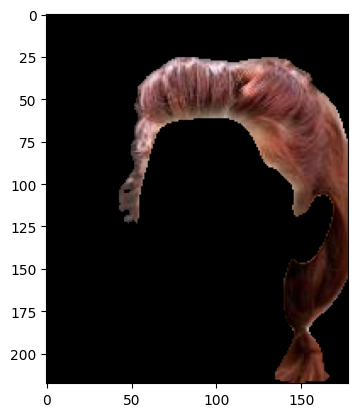

Average Color (RGB): (np.int64(113), np.int64(69), np.int64(62))
Dominant Color (RGB): (np.int64(121), np.int64(71), np.int64(62))
Color Comparison Results:
black - Avg Distance: 28.972595530622996, Dominant Distance: 30.773968069575528
brown - Avg Distance: 7.255332564710856, Dominant Distance: 8.66789145178109
dark_brown - Avg Distance: 16.32066144055113, Dominant Distance: 18.118790634230646
blonde - Avg Distance: 39.08868594684809, Dominant Distance: 37.47944064289266
dark_blonde - Avg Distance: 23.9333641816845, Dominant Distance: 23.10796618342641
red - Avg Distance: 11.716425181702581, Dominant Distance: 11.916787998631895
grey - Avg Distance: 17.639631748990062, Dominant Distance: 18.964244544916568
The closest color classification is: brown
Processing image: 000045.jpg


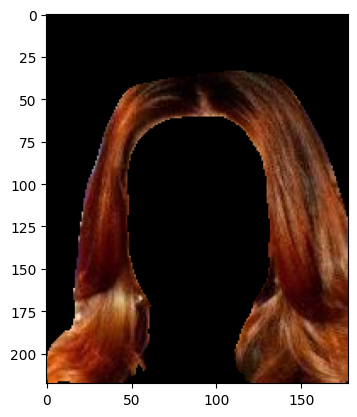

Average Color (RGB): (np.int64(104), np.int64(46), np.int64(24))
Dominant Color (RGB): (np.int64(60), np.int64(15), np.int64(7))
Color Comparison Results:
black - Avg Distance: 27.613783080483792, Dominant Distance: 20.61832299448452
brown - Avg Distance: 9.57461769817892, Dominant Distance: 15.124527315814381
dark_brown - Avg Distance: 15.298621817242994, Dominant Distance: 11.625789687817964
blonde - Avg Distance: 44.147933587880146, Dominant Distance: 53.80970803669127
dark_blonde - Avg Distance: 25.745962021362697, Dominant Distance: 35.98727617251181
red - Avg Distance: 8.249970853341502, Dominant Distance: 9.682102207329917
grey - Avg Distance: 22.42789338512689, Dominant Distance: 25.475257689218235
The closest color classification is: red
Processing image: 000170.jpg


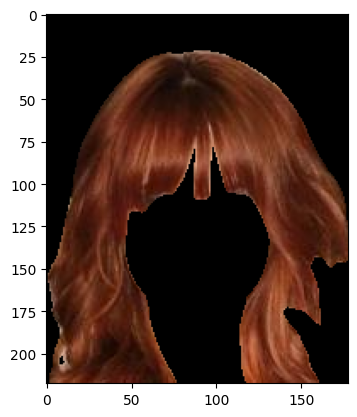

Average Color (RGB): (np.int64(101), np.int64(47), np.int64(28))
Dominant Color (RGB): (np.int64(71), np.int64(27), np.int64(13))
Color Comparison Results:
black - Avg Distance: 26.915974480342385, Dominant Distance: 21.84916448425575
brown - Avg Distance: 8.656311219048042, Dominant Distance: 11.801128722049615
dark_brown - Avg Distance: 14.387679698489448, Dominant Distance: 10.762281349637522
blonde - Avg Distance: 44.30799824313217, Dominant Distance: 50.1975283385853
dark_blonde - Avg Distance: 25.92163205538327, Dominant Distance: 31.703492342357308
red - Avg Distance: 7.831394352503767, Dominant Distance: 8.69985413005073
grey - Avg Distance: 21.74355958332864, Dominant Distance: 23.557232027903744
The closest color classification is: red
Processing image: 000128.jpg


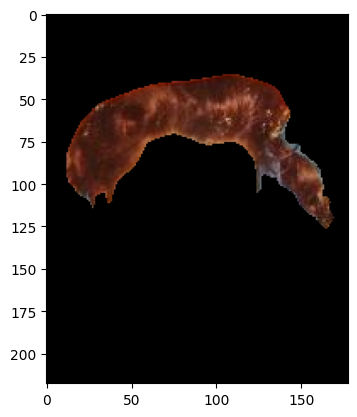

Average Color (RGB): (np.int64(96), np.int64(46), np.int64(32))
Dominant Color (RGB): (np.int64(75), np.int64(30), np.int64(19))
Color Comparison Results:
black - Avg Distance: 25.746422847300387, Dominant Distance: 22.299853599317885
brown - Avg Distance: 8.093940273222183, Dominant Distance: 11.121963951447336
dark_brown - Avg Distance: 13.139943149534178, Dominant Distance: 10.880186358421762
blonde - Avg Distance: 45.288260700465315, Dominant Distance: 49.712640229196325
dark_blonde - Avg Distance: 27.078499272295016, Dominant Distance: 31.391076709990568
red - Avg Distance: 6.949458120436727, Dominant Distance: 7.667421637563228
grey - Avg Distance: 21.101983574110058, Dominant Distance: 22.969020555154874
The closest color classification is: red
Processing image: 000088.jpg


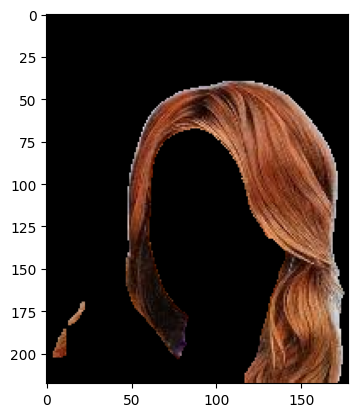

Average Color (RGB): (np.int64(131), np.int64(76), np.int64(53))
Dominant Color (RGB): (np.int64(141), np.int64(75), np.int64(46))
Color Comparison Results:
black - Avg Distance: 33.225750155232255, Dominant Distance: 35.07010590539289
brown - Avg Distance: 10.240897470672994, Dominant Distance: 12.802852486982626
dark_brown - Avg Distance: 20.493811198607418, Dominant Distance: 22.64484201925295
blonde - Avg Distance: 32.95628741364124, Dominant Distance: 32.18453655531527
dark_blonde - Avg Distance: 18.482341061934395, Dominant Distance: 18.48044624365535
red - Avg Distance: 14.828299896005486, Dominant Distance: 15.799291301320757
grey - Avg Distance: 20.60573589494599, Dominant Distance: 22.55252137079922
The closest color classification is: brown
Processing image: 000155.jpg


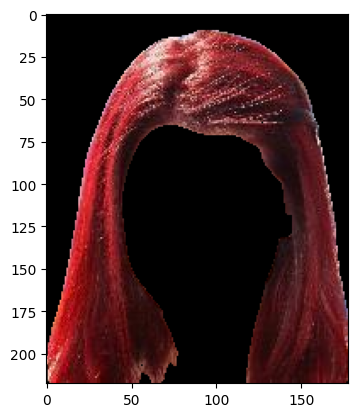

Average Color (RGB): (np.int64(108), np.int64(38), np.int64(41))
Dominant Color (RGB): (np.int64(74), np.int64(20), np.int64(23))
Color Comparison Results:
black - Avg Distance: 28.002017071825176, Dominant Distance: 22.832435012634733
brown - Avg Distance: 13.062515485247056, Dominant Distance: 14.842441415031722
dark_brown - Avg Distance: 16.88483367432595, Dominant Distance: 13.39000975380798
blonde - Avg Distance: 48.55070410454136, Dominant Distance: 53.26265005006264
dark_blonde - Avg Distance: 32.43120831729049, Dominant Distance: 36.17215477101732
red - Avg Distance: 3.97174618593715, Dominant Distance: 7.119083454867262
grey - Avg Distance: 23.394862755712587, Dominant Distance: 24.899939077575194
The closest color classification is: red
Processing image: 000189.jpg


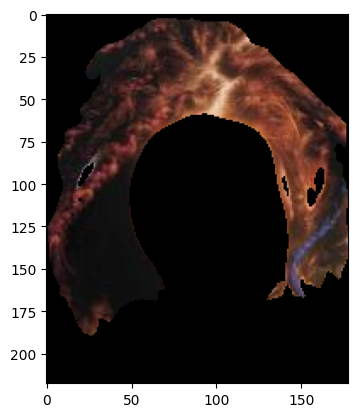

Average Color (RGB): (np.int64(75), np.int64(45), np.int64(37))
Dominant Color (RGB): (np.int64(35), np.int64(23), np.int64(22))
Color Comparison Results:
black - Avg Distance: 20.206901192179227, Dominant Distance: 9.472145530017336
brown - Avg Distance: 6.548274199070469, Dominant Distance: 16.143634842147158
dark_brown - Avg Distance: 7.069541455310718, Dominant Distance: 5.697413507225509
blonde - Avg Distance: 47.109124903732294, Dominant Distance: 54.493151980531884
dark_blonde - Avg Distance: 28.75153234384879, Dominant Distance: 36.78732613536683
red - Avg Distance: 11.150527361536922, Dominant Distance: 19.58122140789914
grey - Avg Distance: 17.459772516049505, Dominant Distance: 19.402641373841895
The closest color classification is: dark_brown
Processing image: 000257.jpg


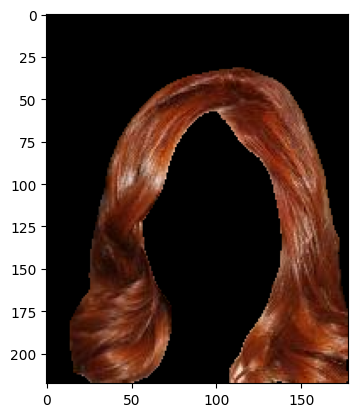

Average Color (RGB): (np.int64(117), np.int64(54), np.int64(33))
Dominant Color (RGB): (np.int64(82), np.int64(28), np.int64(12))
Color Comparison Results:
black - Avg Distance: 29.8706515615544, Dominant Distance: 24.15352543685788
brown - Avg Distance: 9.810479295725536, Dominant Distance: 12.041685935513284
dark_brown - Avg Distance: 17.386288969365573, Dominant Distance: 12.975464452268525
blonde - Avg Distance: 41.5134393290618, Dominant Distance: 49.30255424612882
dark_blonde - Avg Distance: 24.203083302885606, Dominant Distance: 30.9334820633758
red - Avg Distance: 8.995792634815725, Dominant Distance: 6.925023260174809
grey - Avg Distance: 22.144786900564174, Dominant Distance: 24.259787498746775
The closest color classification is: red
Processing folder: Blonde
Processing image: 000024.jpg


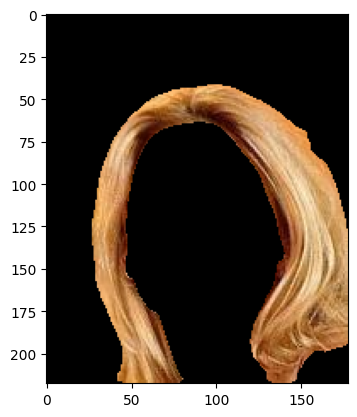

Average Color (RGB): (np.int64(189), np.int64(133), np.int64(81))
Dominant Color (RGB): (np.int64(226), np.int64(174), np.int64(118))
Color Comparison Results:
black - Avg Distance: 51.21598179056955, Dominant Distance: 66.68044896370115
brown - Avg Distance: 30.85609923553644, Dominant Distance: 45.741744839641555
dark_brown - Avg Distance: 40.57282501455859, Dominant Distance: 57.814628862665415
blonde - Avg Distance: 10.771387230470939, Dominant Distance: 7.610653872898119
dark_blonde - Avg Distance: 12.213278123112966, Dominant Distance: 21.678064912984915
red - Avg Distance: 37.79450606446093, Dominant Distance: 55.21318985605143
grey - Avg Distance: 33.03770091302612, Dominant Distance: 43.66256425897877
The closest color classification is: blonde
Processing image: 000029.jpg


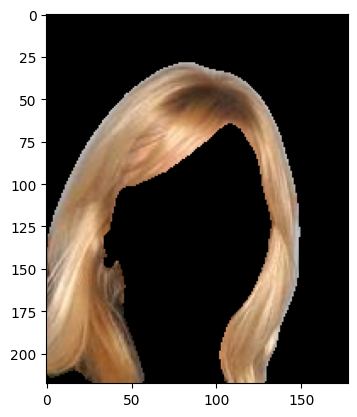

Average Color (RGB): (np.int64(175), np.int64(138), np.int64(105))
Dominant Color (RGB): (np.int64(176), np.int64(136), np.int64(99))
Color Comparison Results:
black - Avg Distance: 49.51086227860516, Dominant Distance: 49.373840886459924
brown - Avg Distance: 29.50976435812505, Dominant Distance: 29.199023582230843
dark_brown - Avg Distance: 39.0465575791851, Dominant Distance: 38.81400611029464
blonde - Avg Distance: 10.171260253313326, Dominant Distance: 10.07251872709014
dark_blonde - Avg Distance: 12.202727539068551, Dominant Distance: 11.425222168355143
red - Avg Distance: 37.460353688737555, Dominant Distance: 37.08357359608235
grey - Avg Distance: 30.254437421717995, Dominant Distance: 30.37176114613902
The closest color classification is: blonde
Processing image: 000054.jpg


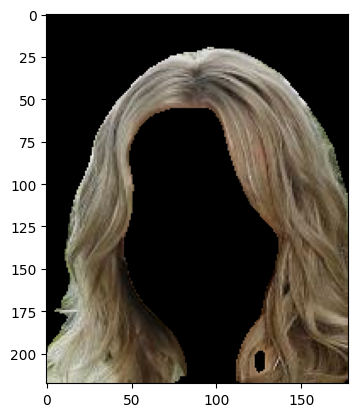

Average Color (RGB): (np.int64(120), np.int64(107), np.int64(86))
Dominant Color (RGB): (np.int64(126), np.int64(111), np.int64(89))
Color Comparison Results:
black - Avg Distance: 34.422291035916594, Dominant Distance: 36.110608335500174
brown - Avg Distance: 17.04115108499941, Dominant Distance: 18.075039602511833
dark_brown - Avg Distance: 24.84967652324678, Dominant Distance: 26.323317676767594
blonde - Avg Distance: 22.78916089394305, Dominant Distance: 20.886954982076197
dark_blonde - Avg Distance: 11.163400542165302, Dominant Distance: 10.143299096585517
red - Avg Distance: 28.824068928022704, Dominant Distance: 29.496920871612026
grey - Avg Distance: 14.596541462065245, Dominant Distance: 16.193756751347603
The closest color classification is: dark_blonde
Processing image: 007.jpg


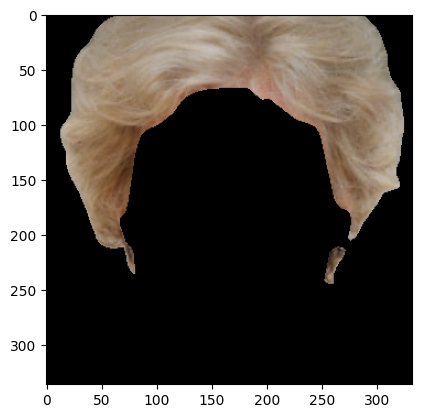

Average Color (RGB): (np.int64(155), np.int64(133), np.int64(111))
Dominant Color (RGB): (np.int64(153), np.int64(130), np.int64(107))
Color Comparison Results:
black - Avg Distance: 44.95188714887075, Dominant Distance: 44.03326345714323
brown - Avg Distance: 25.890227938283996, Dominant Distance: 24.719043363889874
dark_brown - Avg Distance: 34.95265834454345, Dominant Distance: 33.879805841402806
blonde - Avg Distance: 13.524052805194177, Dominant Distance: 14.017485708315375
dark_blonde - Avg Distance: 11.947109611883988, Dominant Distance: 11.083688188636591
red - Avg Distance: 35.23947902938406, Dominant Distance: 34.17460469825732
grey - Avg Distance: 24.722464607955924, Dominant Distance: 23.91686969587031
The closest color classification is: dark_blonde
Processing image: 000019.jpg


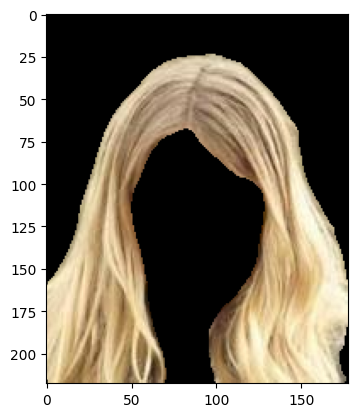

Average Color (RGB): (np.int64(199), np.int64(174), np.int64(135))
Dominant Color (RGB): (np.int64(237), np.int64(217), np.int64(178))
Color Comparison Results:
black - Avg Distance: 62.375849799885806, Dominant Distance: 82.46994411754683
brown - Avg Distance: 43.75844657084661, Dominant Distance: 53.154958201342446
dark_brown - Avg Distance: 53.98880159032878, Dominant Distance: 71.95178210314754
blonde - Avg Distance: 5.595983236606964, Dominant Distance: 14.761844013514105
dark_blonde - Avg Distance: 20.077467906680695, Dominant Distance: 30.18284477951996
red - Avg Distance: 53.48093601666337, Dominant Distance: 65.54018095882329
grey - Avg Distance: 39.895953107508234, Dominant Distance: 48.24759613279161
The closest color classification is: blonde
Processing image: 000018.jpg


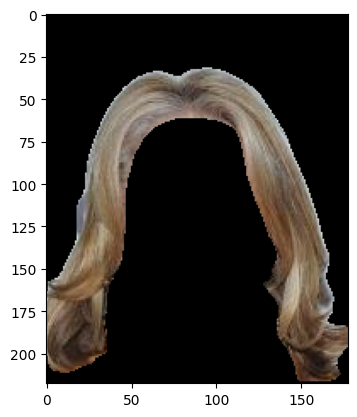

Average Color (RGB): (np.int64(125), np.int64(107), np.int64(91))
Dominant Color (RGB): (np.int64(128), np.int64(108), np.int64(88))
Color Comparison Results:
black - Avg Distance: 34.853822565092834, Dominant Distance: 35.71576529507095
brown - Avg Distance: 15.508515993744238, Dominant Distance: 16.0969191906556
dark_brown - Avg Distance: 24.38279370435154, Dominant Distance: 25.133573964243528
blonde - Avg Distance: 23.00400677616483, Dominant Distance: 21.77745898412728
dark_blonde - Avg Distance: 12.312459917948848, Dominant Distance: 10.669383067375053
red - Avg Distance: 26.67486045770968, Dominant Distance: 27.168985372728603
grey - Avg Distance: 14.804361308875983, Dominant Distance: 16.11833782800093
The closest color classification is: dark_blonde
Processing image: 000013.jpg


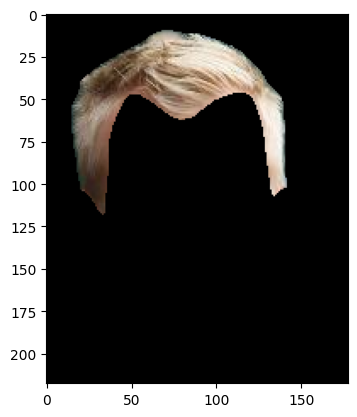

Average Color (RGB): (np.int64(161), np.int64(141), np.int64(122))
Dominant Color (RGB): (np.int64(161), np.int64(137), np.int64(116))
Color Comparison Results:
black - Avg Distance: 47.597417280382814, Dominant Distance: 46.72826232335504
brown - Avg Distance: 29.129915211899046, Dominant Distance: 27.568581559550083
dark_brown - Avg Distance: 37.966541009200974, Dominant Distance: 36.70030644744199
blonde - Avg Distance: 12.742423458533883, Dominant Distance: 12.907595404351378
dark_blonde - Avg Distance: 14.497239933976264, Dominant Distance: 13.305569294661451
red - Avg Distance: 38.09992428639334, Dominant Distance: 36.41551292424412
grey - Avg Distance: 27.19574642825566, Dominant Distance: 26.553359174151414
The closest color classification is: blonde
Processing image: 0000012.jpg


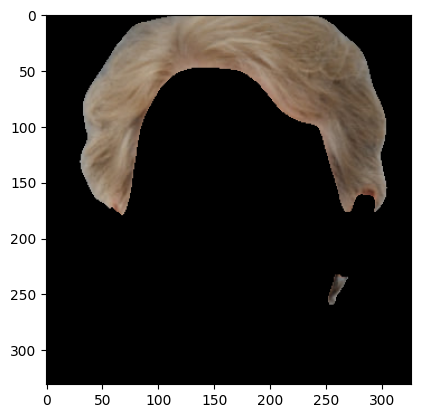

Average Color (RGB): (np.int64(137), np.int64(117), np.int64(97))
Dominant Color (RGB): (np.int64(136), np.int64(114), np.int64(94))
Color Comparison Results:
black - Avg Distance: 38.798293632834934, Dominant Distance: 38.078448119957095
brown - Avg Distance: 19.406879075582673, Dominant Distance: 18.181105849556097
dark_brown - Avg Distance: 28.46638128177459, Dominant Distance: 27.46188477851986
blonde - Avg Distance: 18.64309061980999, Dominant Distance: 19.541113641910577
dark_blonde - Avg Distance: 10.384038737795551, Dominant Distance: 10.400280973659742
red - Avg Distance: 29.858707321843198, Dominant Distance: 28.581605920747155
grey - Avg Distance: 18.66007221806997, Dominant Distance: 18.21728892800226
The closest color classification is: dark_blonde
Processing image: 000094.jpg


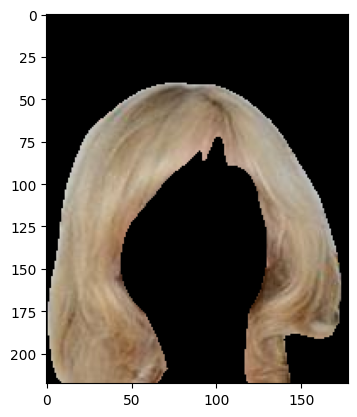

Average Color (RGB): (np.int64(166), np.int64(144), np.int64(118))
Dominant Color (RGB): (np.int64(165), np.int64(139), np.int64(110))
Color Comparison Results:
black - Avg Distance: 49.26487822792218, Dominant Distance: 48.0466605820698
brown - Avg Distance: 30.849303854385496, Dominant Distance: 28.97563989548607
dark_brown - Avg Distance: 39.68987981761726, Dominant Distance: 38.090488609576184
blonde - Avg Distance: 10.10158633115914, Dominant Distance: 10.319689732112447
dark_blonde - Avg Distance: 13.527714786607838, Dominant Distance: 11.814118842856242
red - Avg Distance: 39.81518973962358, Dominant Distance: 37.9129320261281
grey - Avg Distance: 29.208966358659794, Dominant Distance: 28.258768214443954
The closest color classification is: blonde
Processing image: 000022.jpg


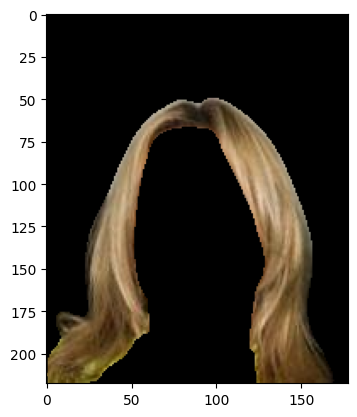

Average Color (RGB): (np.int64(131), np.int64(105), np.int64(69))
Dominant Color (RGB): (np.int64(179), np.int64(151), np.int64(114))
Color Comparison Results:
black - Avg Distance: 36.71405937181498, Dominant Distance: 53.23048016422295
brown - Avg Distance: 17.057202539724546, Dominant Distance: 34.79824705738841
dark_brown - Avg Distance: 26.07790032711027, Dominant Distance: 43.73453789630357
blonde - Avg Distance: 20.81584114099248, Dominant Distance: 5.977530164979513
dark_blonde - Avg Distance: 6.17767219749339, Dominant Distance: 14.021515200839847
red - Avg Distance: 28.030593266941256, Dominant Distance: 43.383920562286306
grey - Avg Distance: 19.14743084556556, Dominant Distance: 33.55739605625308
The closest color classification is: dark_blonde
Processing folder: Black
Processing image: 000055.jpg


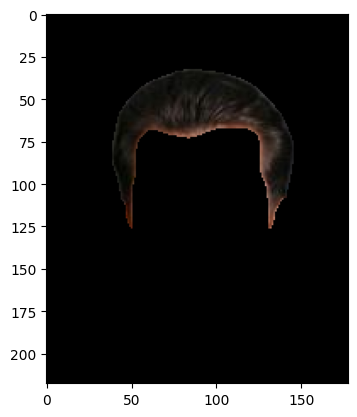

Average Color (RGB): (np.int64(40), np.int64(32), np.int64(26))
Dominant Color (RGB): (np.int64(22), np.int64(20), np.int64(15))
Color Comparison Results:
black - Avg Distance: 9.834735628135002, Dominant Distance: 4.7313270280225055
brown - Avg Distance: 14.647476718802768, Dominant Distance: 20.463847448706623
dark_brown - Avg Distance: 4.869148525196003, Dominant Distance: 10.579860565939052
blonde - Avg Distance: 51.407530258407334, Dominant Distance: 55.196867186304104
dark_blonde - Avg Distance: 33.06968743281755, Dominant Distance: 37.39080586898935
red - Avg Distance: 20.92849337781474, Dominant Distance: 25.83104199005859
grey - Avg Distance: 16.552641726888247, Dominant Distance: 19.729130638962257
The closest color classification is: black
Processing image: 000047.jpg


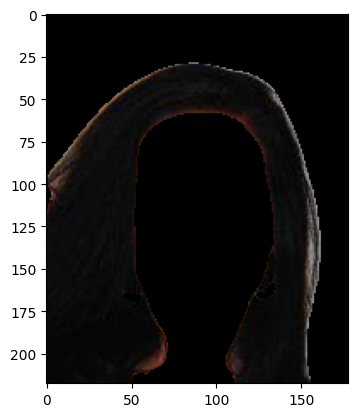

Average Color (RGB): (np.int64(20), np.int64(17), np.int64(16))
Dominant Color (RGB): (np.int64(12), np.int64(11), np.int64(11))
Color Comparison Results:
black - Avg Distance: 3.546545659088553, Dominant Distance: 1.842168874334463
brown - Avg Distance: 20.61113787222834, Dominant Distance: 22.37133333036035
dark_brown - Avg Distance: 10.4371072774721, Dominant Distance: 12.250697148518652
blonde - Avg Distance: 56.232487782592464, Dominant Distance: 57.457204781230175
dark_blonde - Avg Distance: 38.672887679414316, Dominant Distance: 40.06110691533746
red - Avg Distance: 24.84682076383944, Dominant Distance: 26.296225837682954
grey - Avg Distance: 20.219514884312588, Dominant Distance: 21.434446786968916
The closest color classification is: black
Processing image: 000008765.jpg


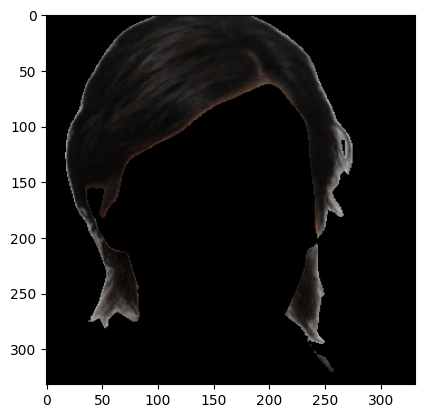

Average Color (RGB): (np.int64(35), np.int64(32), np.int64(31))
Dominant Color (RGB): (np.int64(22), np.int64(19), np.int64(18))
Color Comparison Results:
black - Avg Distance: 7.858750447848678, Dominant Distance: 4.059861780390102
brown - Avg Distance: 17.024934588955944, Dominant Distance: 20.1335039310009
dark_brown - Avg Distance: 7.999552895439126, Dominant Distance: 10.012800837092403
blonde - Avg Distance: 52.684536795621014, Dominant Distance: 55.82284297750861
dark_blonde - Avg Distance: 34.97473150307431, Dominant Distance: 38.23463037478898
red - Avg Distance: 22.90487161635055, Dominant Distance: 24.525166484467963
grey - Avg Distance: 15.874958057124553, Dominant Distance: 19.74037088134831
The closest color classification is: black
Processing image: 000345.jpg


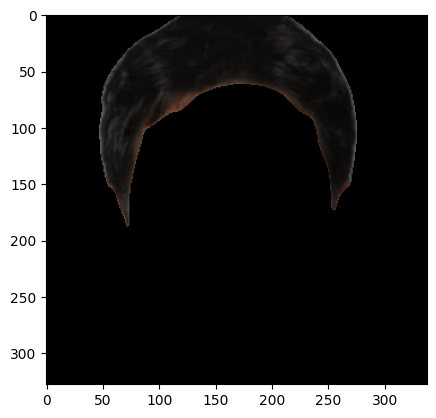

Average Color (RGB): (np.int64(25), np.int64(22), np.int64(20))
Dominant Color (RGB): (np.int64(16), np.int64(15), np.int64(14))
Color Comparison Results:
black - Avg Distance: 4.963084065908771, Dominant Distance: 2.628851074270112
brown - Avg Distance: 19.296062890266267, Dominant Distance: 21.68234472767249
dark_brown - Avg Distance: 9.280134380088763, Dominant Distance: 11.648391310580816
blonde - Avg Distance: 54.93887919635552, Dominant Distance: 56.70995352002411
dark_blonde - Avg Distance: 37.209136045097786, Dominant Distance: 39.2139774566844
red - Avg Distance: 24.141391576871968, Dominant Distance: 25.96595882297345
grey - Avg Distance: 18.971335277175903, Dominant Distance: 20.701955906612348
The closest color classification is: black
Processing image: 000007.jpg


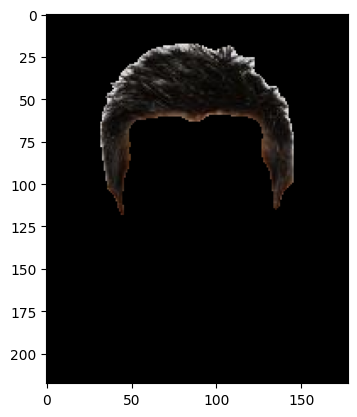

Average Color (RGB): (np.int64(49), np.int64(42), np.int64(38))
Dominant Color (RGB): (np.int64(26), np.int64(21), np.int64(17))
Color Comparison Results:
black - Avg Distance: 11.913499523256995, Dominant Distance: 5.609936767296284
brown - Avg Distance: 12.915117914638454, Dominant Distance: 18.715221508446493
dark_brown - Avg Distance: 5.332834774839884, Dominant Distance: 8.41345804035839
blonde - Avg Distance: 49.35376357943617, Dominant Distance: 54.74661673116676
dark_blonde - Avg Distance: 31.1978995563592, Dominant Distance: 36.83864285974438
red - Avg Distance: 20.506240648531136, Dominant Distance: 23.513198076430662
grey - Avg Distance: 13.24548469493219, Dominant Distance: 19.377344031890427
The closest color classification is: dark_brown
Processing image: 0001345.jpg


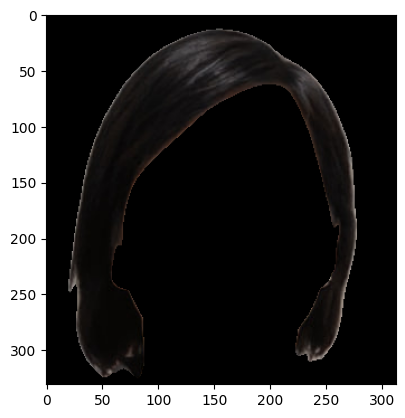

Average Color (RGB): (np.int64(29), np.int64(25), np.int64(24))
Dominant Color (RGB): (np.int64(17), np.int64(15), np.int64(13))
Color Comparison Results:
black - Avg Distance: 6.135186188707022, Dominant Distance: 2.879630766903277
brown - Avg Distance: 18.187592014260176, Dominant Distance: 21.34858175830816
dark_brown - Avg Distance: 8.250410859699935, Dominant Distance: 11.221222015804294
blonde - Avg Distance: 54.33392979920913, Dominant Distance: 56.52535975236811
dark_blonde - Avg Distance: 36.65009115504135, Dominant Distance: 38.95007768210907
red - Avg Distance: 23.10282685941793, Dominant Distance: 25.68669775408164
grey - Avg Distance: 18.046860531370957, Dominant Distance: 20.697724001581932
The closest color classification is: black
Processing image: 000008.jpg


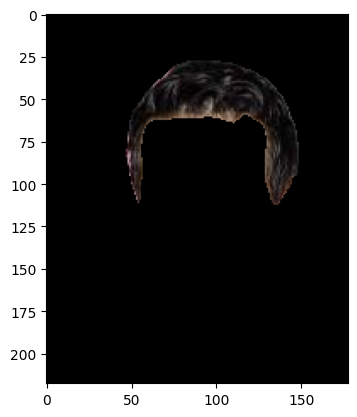

Average Color (RGB): (np.int64(40), np.int64(33), np.int64(31))
Dominant Color (RGB): (np.int64(18), np.int64(15), np.int64(14))
Color Comparison Results:
black - Avg Distance: 9.361712596889006, Dominant Distance: 3.0781586329724617
brown - Avg Distance: 15.04794561983516, Dominant Distance: 21.051845257084633
dark_brown - Avg Distance: 5.538076983579205, Dominant Distance: 10.837500699351303
blonde - Avg Distance: 52.00311831065706, Dominant Distance: 56.605536723471594
dark_blonde - Avg Distance: 34.11704854291979, Dominant Distance: 39.07340103650368
red - Avg Distance: 20.869605375195423, Dominant Distance: 25.151036399351693
grey - Avg Distance: 15.82873034755096, Dominant Distance: 20.65502305460828
The closest color classification is: black
Processing image: 000023.jpg


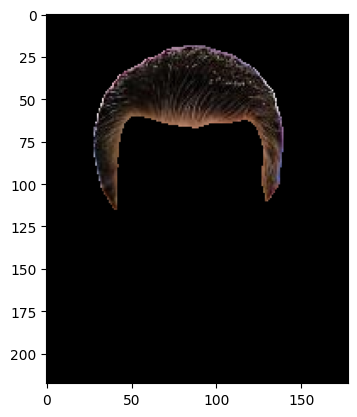

Average Color (RGB): (np.int64(59), np.int64(44), np.int64(39))
Dominant Color (RGB): (np.int64(29), np.int64(21), np.int64(17))
Color Comparison Results:
black - Avg Distance: 14.98759782905754, Dominant Distance: 7.033320161891109
brown - Avg Distance: 9.387154825375804, Dominant Distance: 17.5314490453917
dark_brown - Avg Distance: 2.824458043319835, Dominant Distance: 6.857313552617008
blonde - Avg Distance: 48.34162871552136, Dominant Distance: 54.59427196235824
dark_blonde - Avg Distance: 30.063243582914037, Dominant Distance: 36.642943111008734
red - Avg Distance: 16.72535761566344, Dominant Distance: 21.800028780039778
grey - Avg Distance: 14.117873479678211, Dominant Distance: 19.569625573482554
The closest color classification is: dark_brown
Processing image: 00012344.jpg


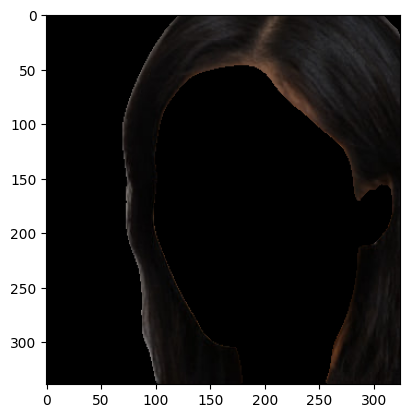

Average Color (RGB): (np.int64(26), np.int64(22), np.int64(20))
Dominant Color (RGB): (np.int64(14), np.int64(12), np.int64(11))
Color Comparison Results:
black - Avg Distance: 5.3233868110293265, Dominant Distance: 2.1982322634953646
brown - Avg Distance: 18.86478078148545, Dominant Distance: 21.91154946961841
dark_brown - Avg Distance: 8.705234349665206, Dominant Distance: 11.730212319595255
blonde - Avg Distance: 54.876060932578824, Dominant Distance: 57.139879947255636
dark_blonde - Avg Distance: 37.125643971561026, Dominant Distance: 39.65923448023021
red - Avg Distance: 23.573172045685826, Dominant Distance: 25.912125592580452
grey - Avg Distance: 18.982693321652274, Dominant Distance: 21.24896594546443
The closest color classification is: black
Processing image: 000046.jpg


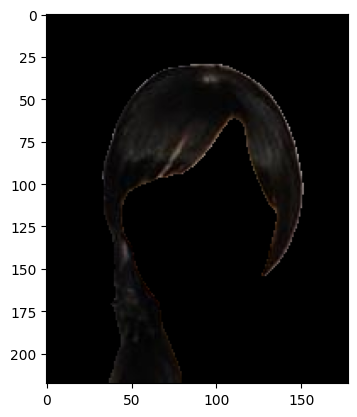

Average Color (RGB): (np.int64(24), np.int64(21), np.int64(19))
Dominant Color (RGB): (np.int64(14), np.int64(12), np.int64(11))
Color Comparison Results:
black - Avg Distance: 4.664364193695354, Dominant Distance: 2.1982322634953646
brown - Avg Distance: 19.57010726283385, Dominant Distance: 21.91154946961841
dark_brown - Avg Distance: 9.511690350805955, Dominant Distance: 11.730212319595255
blonde - Avg Distance: 55.186040611497035, Dominant Distance: 57.139879947255636
dark_blonde - Avg Distance: 37.4761550330694, Dominant Distance: 39.65923448023021
red - Avg Distance: 24.30926646055653, Dominant Distance: 25.912125592580452
grey - Avg Distance: 19.249054077360526, Dominant Distance: 21.24896594546443
The closest color classification is: black


In [ ]:
image_dir = os.path.join(extracted_dir, "Hair_Data")
true_labels = []
predicted_labels = []

for folder_name in os.listdir(image_dir):
    folder_path = os.path.join(image_dir, folder_name)
    if os.path.isdir(folder_path):
        print(f"Processing folder: {folder_name}")
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(folder_path, filename)
                print(f"Processing image: {filename}")
                try:
                    # Run classification and store labels in lowercase
                    predicted_label = Classify_hair(image_path, colorSpaces).lower()
                    true_labels.append(folder_name.lower())
                    predicted_labels.append(predicted_label)
                except Exception as e:
                    print(f"Error processing {image_path}: {e}")



In [ ]:
# Calculate and display accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate and display the classification report
report = classification_report(true_labels, predicted_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("Classification Report:")
print(report_df)


Accuracy: 39.13%
Classification Report:
              precision    recall  f1-score    support
black          1.000000  0.800000  0.888889  10.000000
blonde         1.000000  0.500000  0.666667  10.000000
brown          0.153846  0.200000  0.173913  10.000000
dark blonde    0.000000  0.000000  0.000000  10.000000
dark brown     0.000000  0.000000  0.000000   9.000000
dark_blonde    0.000000  0.000000  0.000000   0.000000
dark_brown     0.000000  0.000000  0.000000   0.000000
grey           1.000000  0.500000  0.666667  10.000000
red            1.000000  0.700000  0.823529  10.000000
accuracy       0.391304  0.391304  0.391304   0.391304
macro avg      0.461538  0.300000  0.357741  69.000000
weighted avg   0.602007  0.391304  0.466618  69.000000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

In [ ]:
# Save results to a DataFrame and export as CSV
results_df = pd.DataFrame({
    'Image': [os.path.basename(path) for path in true_labels],
    'True Label': true_labels,
    'Predicted Label': predicted_labels
})
results_df.to_csv('/content/LAB_results.csv', index=False)